# Laboratorium 3: Klasyfikacja — Indukcja drzew decyzyjnych 

In [134]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from ucimlrepo import fetch_ucirepo
from tqdm.auto import tqdm

from sklearn.datasets import load_wine
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.impute import SimpleImputer
from sklearn.model_selection import (
    train_test_split, cross_val_score, KFold, StratifiedKFold, GridSearchCV
)
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import (
    train_test_split, cross_val_score, cross_val_predict, KFold, StratifiedKFold, GridSearchCV
)
from sklearn.exceptions import UndefinedMetricWarning

warnings.filterwarnings('ignore', category=UndefinedMetricWarning)
warnings.filterwarnings('ignore', category=UserWarning)
pd.set_option('display.float_format', '{:.4f}'.format)

## 1. Zbiór danych GLASS

In [135]:
glass = fetch_ucirepo(id=42)
X_glass = glass.data.features
y_glass = glass.data.targets.values.ravel()

feature_names = list(X_glass.columns)
class_names = [str(c) for c in sorted(np.unique(y_glass))]

print(f'Shape: {X_glass.shape}')
print(f'Klasy: {class_names}')
print(f'Rozkład:\n{pd.Series(y_glass).value_counts().sort_index()}')

Shape: (214, 9)
Klasy: ['1', '2', '3', '5', '6', '7']
Rozkład:
1    70
2    76
3    17
5    13
6     9
7    29
Name: count, dtype: int64


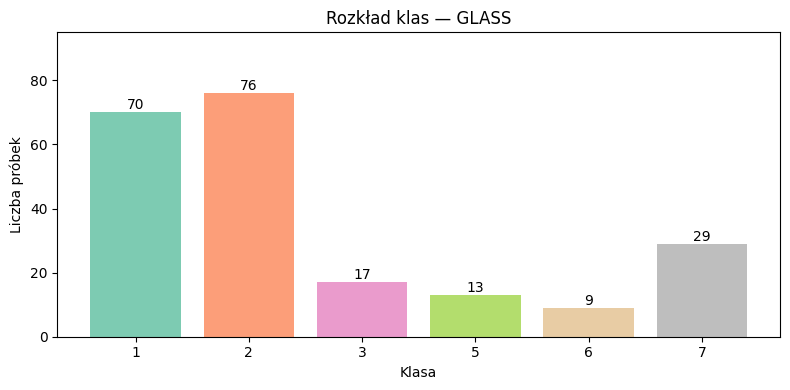

In [136]:
vc = pd.Series(y_glass).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
colors = plt.cm.Set2(np.linspace(0, 1, len(vc)))
bars = ax.bar(vc.index.astype(str), vc.values, color=colors, alpha=0.85)
for bar, cnt in zip(bars, vc.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(cnt), ha='center', fontsize=10)
ax.set_title('Rozkład klas — GLASS')
ax.set_ylabel('Liczba próbek')
ax.set_xlabel('Klasa')
ax.set_ylim(0, max(vc.values) * 1.25)
plt.tight_layout()
plt.show()

In [137]:
X_train, X_test, y_train, y_test = train_test_split(
    X_glass.values, y_glass, test_size=0.2, stratify=y_glass
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Rozkład klas train: {np.bincount(y_train)}')
print(f'Rozkład klas test:  {np.bincount(y_test)}')

Train: (171, 9), Test: (43, 9)
Rozkład klas train: [ 0 56 61 14  0 10  7 23]
Rozkład klas test:  [ 0 14 15  3  0  3  2  6]


## 2. Drzewo decyzyjne — domyślne parametry

In [138]:
from sklearn.metrics import classification_report

def eval_clf(clf, X_train, y_train, X_test, y_test, avg='macro'):
    if not hasattr(clf, 'classes_'):
        clf.fit(X_train, y_train)
    
    yp_tr = clf.predict(X_train)
    yp_te = clf.predict(X_test)
    
    print(f'Głębokość: {clf.get_depth()}, Liście: {clf.get_n_leaves()}')
    print()
    
    metrics = {'Accuracy': accuracy_score, "Bal.Acc": balanced_accuracy_score,
               'Precision': precision_score, 'F1': f1_score}
    
    print(f'{"Metryka":<12} {"Train":>8} {"Test":>8}')
    print('-' * 30)
    for name, fn in metrics.items():
        kw = {} if name == 'Accuracy' or name == 'Bal.Acc' else {'average': avg, 'zero_division': 0}
        print(f'{name:<12} {fn(y_train, yp_tr, **kw):>8.4f} {fn(y_test, yp_te, **kw):>8.4f}')
    
    return yp_te

In [159]:
clf_default = DecisionTreeClassifier()
clf_default.fit(X_train, y_train)
y_test_pred = eval_clf(clf_default, X_train, y_train, X_test, y_test)

Głębokość: 10, Liście: 40

Metryka         Train     Test
------------------------------
Accuracy       1.0000   0.5581
Bal.Acc        1.0000   0.5460
Precision      1.0000   0.5302
F1             1.0000   0.5319


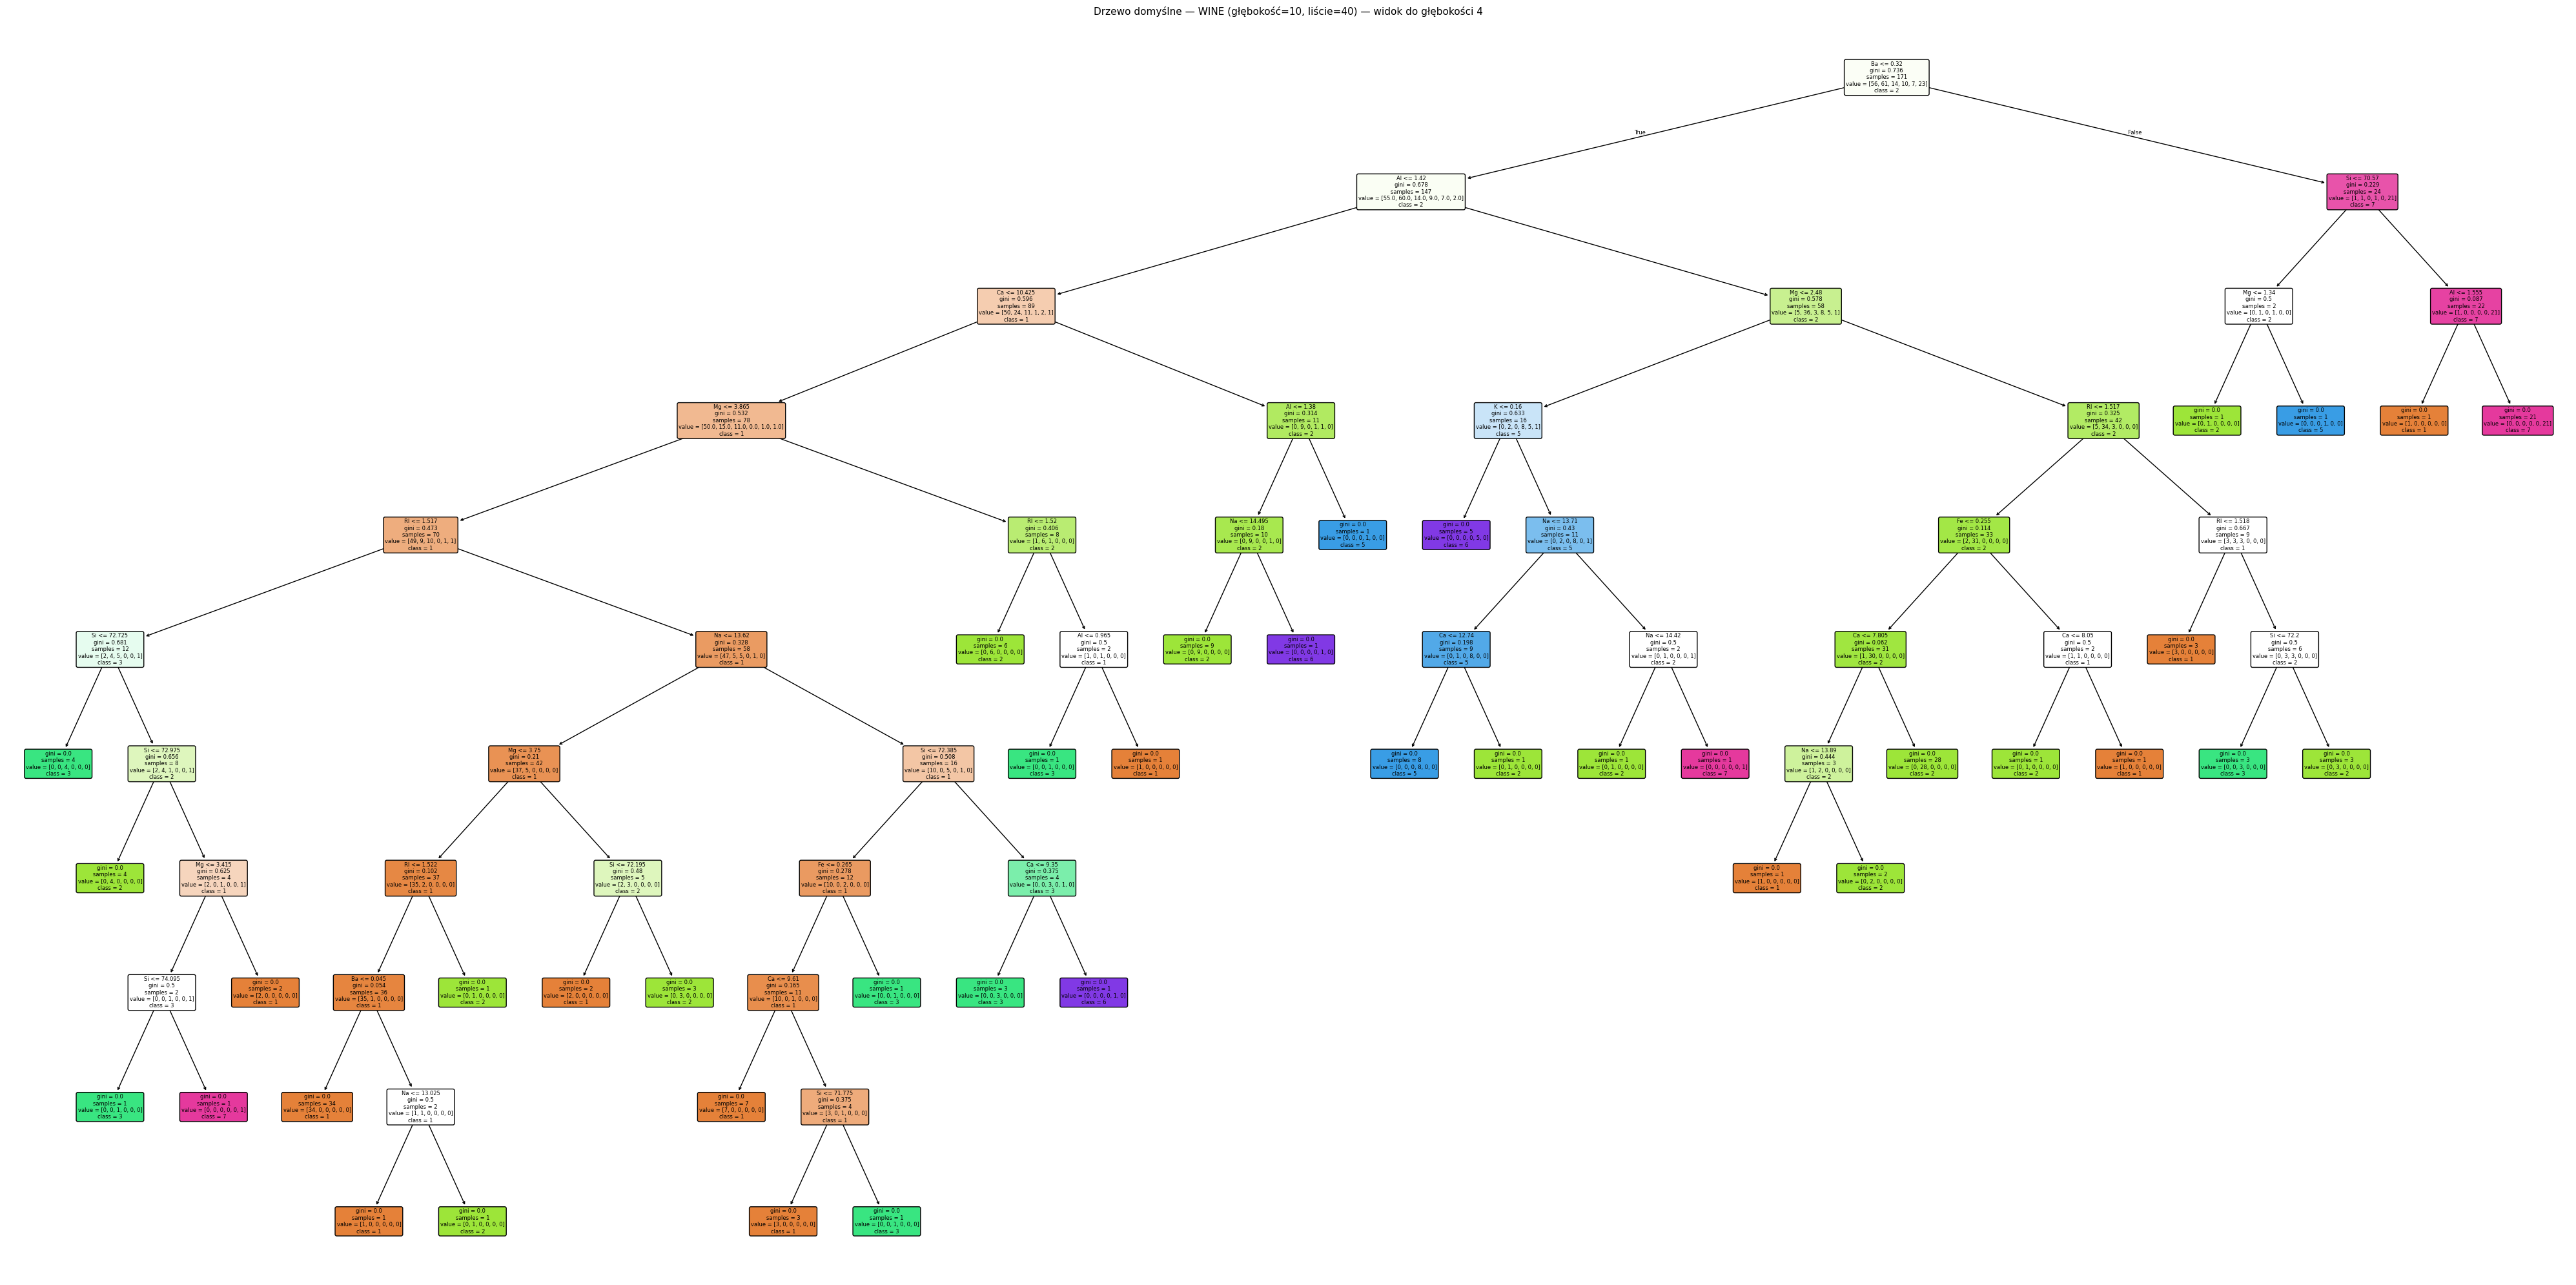

In [140]:
fig, ax = plt.subplots(figsize=(40, 20))
plot_tree(clf_default,
          feature_names=feature_names,
          class_names=class_names,
          filled=True, rounded=True, fontsize=6, ax=ax)
depth  = clf_default.get_depth()
leaves = clf_default.get_n_leaves()
ax.set_title(
    f'Drzewo domyślne — WINE (głębokość={depth}, liście={leaves}) — widok do głębokości 4',
    fontsize=11
)
plt.tight_layout()
plt.show()

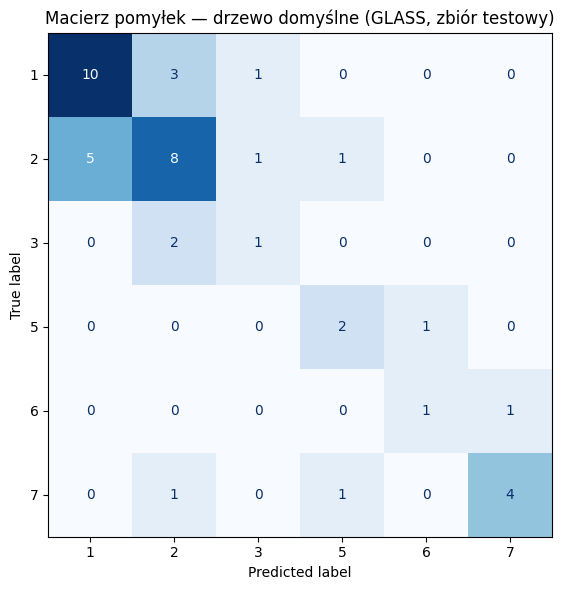

In [141]:
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Macierz pomyłek — drzewo domyślne (GLASS, zbiór testowy)')
plt.tight_layout()
plt.show()

## 3. Strojenie hiperparametrów

### 3.1 `max_depth` — ograniczenie głębokości

max_depth sweep:   0%|          | 0/14 [00:00<?, ?it/s]

Drzewo nasycone przy max_depth=11 (rzeczywista głębokość=10), przerywam sweep.
Najlepsza głębokość (wg CV): max_depth=10, CV balanced acc=0.6704


,train_bacc,test_bacc,cv_mean,cv_std,train_prec,test_prec,n_leaves,actual_depth
max_depth,,,,,,,,
1,0.3161,0.3056,0.3156,0.0171,0.2139,0.2325,2,1
2,0.4021,0.3548,0.3779,0.0270,0.3555,0.3458,4,2
3,0.5742,0.5103,0.4846,0.1206,0.4983,0.4609,8,3
4,0.7240,0.5270,0.5042,0.1473,0.7226,0.5319,12,4
5,0.8431,0.6373,0.5878,0.0816,0.8616,0.6349,18,5
6,0.8749,0.5817,0.6144,0.0767,0.9577,0.6192,26,6
7,0.9218,0.5698,0.6372,0.1149,0.9640,0.5635,30,7
8,0.9781,0.5690,0.6536,0.0781,0.9823,0.6028,35,8
9,0.9854,0.5690,0.6027,0.1177,0.9943,0.6097,38,9


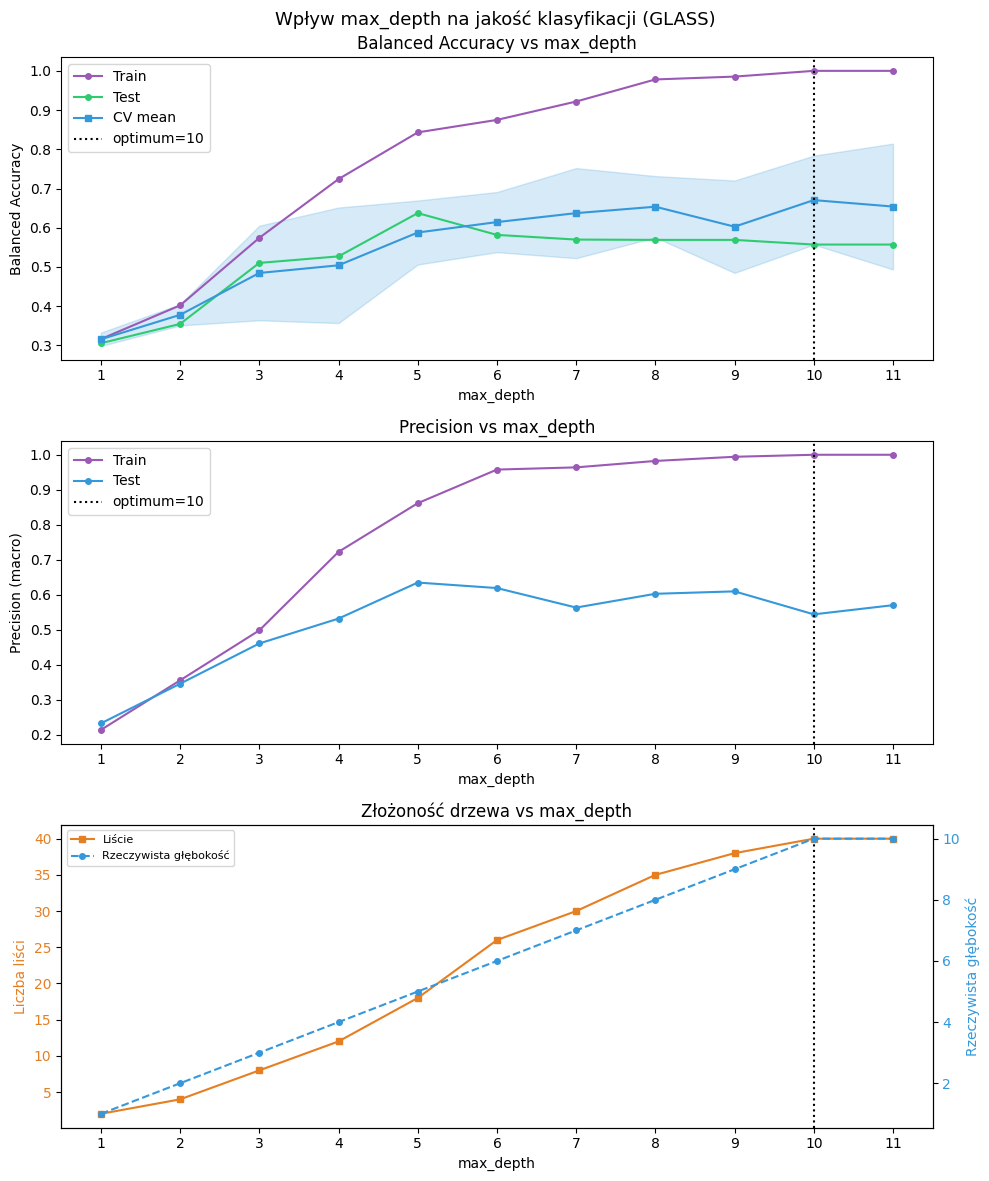

In [142]:
depths = list(range(1, 15))
depth_results = []

skf = StratifiedKFold(n_splits=5, shuffle=True)

for d in tqdm(depths, desc='max_depth sweep'):
    clf = DecisionTreeClassifier(max_depth=d)
    clf.fit(X_train, y_train)
    yp_tr = clf.predict(X_train)
    yp_te = clf.predict(X_test)
    cv_scores = cross_val_score(clf, X_train, y_train, cv=skf, scoring='balanced_accuracy')

    actual_depth = clf.get_depth()
    depth_results.append({
        'max_depth':    d,
        'actual_depth': actual_depth,
        'train_bacc':   balanced_accuracy_score(y_train, yp_tr),
        'test_bacc':    balanced_accuracy_score(y_test, yp_te),
        'cv_mean':      cv_scores.mean(),
        'cv_std':       cv_scores.std(),
        'train_prec':   precision_score(y_train, yp_tr, average='macro', zero_division=0),
        'test_prec':    precision_score(y_test, yp_te, average='macro', zero_division=0),
        'n_leaves':     clf.get_n_leaves(),
    })

    if actual_depth < d:
        print(f'Drzewo nasycone przy max_depth={d} (rzeczywista głębokość={actual_depth}), przerywam sweep.')
        break

df_depth = pd.DataFrame(depth_results).set_index('max_depth')
best_depth = int(df_depth['cv_mean'].idxmax())
print(f'Najlepsza głębokość (wg CV): max_depth={best_depth}, CV balanced acc={df_depth.loc[best_depth, "cv_mean"]:.4f}')

display(df_depth[['train_bacc', 'test_bacc', 'cv_mean', 'cv_std',
                   'train_prec', 'test_prec',
                   'n_leaves', 'actual_depth']].round(4))

fig, axes = plt.subplots(3, 1, figsize=(10, 12))

# 1) Balanced Accuracy: train / test / CV
axes[0].plot(df_depth.index, df_depth['train_bacc'], color='#9b59b6', marker='o', markersize=4, label='Train')
axes[0].plot(df_depth.index, df_depth['test_bacc'],  color='#2ecc71', marker='o', markersize=4, label='Test')
axes[0].plot(df_depth.index, df_depth['cv_mean'],    color='#3498db', marker='s', markersize=4, label='CV mean')
axes[0].fill_between(df_depth.index,
                     df_depth['cv_mean'] - df_depth['cv_std'],
                     df_depth['cv_mean'] + df_depth['cv_std'],
                     alpha=0.2, color='#3498db')
axes[0].axvline(best_depth, color='black', linestyle=':', label=f'optimum={best_depth}')
axes[0].set_ylabel('Balanced Accuracy')
axes[0].set_xlabel('max_depth')
axes[0].set_title('Balanced Accuracy vs max_depth')
axes[0].set_xticks(df_depth.index)
axes[0].legend()

# 2) Precision
axes[1].plot(df_depth.index, df_depth['train_prec'], color='#9b59b6', marker='o', markersize=4, label='Train')
axes[1].plot(df_depth.index, df_depth['test_prec'],  color='#3498db', marker='o', markersize=4, label='Test')
axes[1].axvline(best_depth, color='black', linestyle=':', label=f'optimum={best_depth}')
axes[1].set_ylabel('Precision (macro)')
axes[1].set_xlabel('max_depth')
axes[1].set_title('Precision vs max_depth')
axes[1].set_xticks(df_depth.index)
axes[1].legend()

# 3) Złożoność + rzeczywista głębokość
axes[2].plot(df_depth.index, df_depth['n_leaves'], color='#e67e22', marker='s', markersize=4, label='Liście')
axes[2].axvline(best_depth, color='black', linestyle=':')
axes[2].set_ylabel('Liczba liści', color='#e67e22')
axes[2].tick_params(axis='y', labelcolor='#e67e22')
axes[2].set_xlabel('max_depth')
axes[2].set_title('Złożoność drzewa vs max_depth')
axes[2].set_xticks(df_depth.index)

ax_act = axes[2].twinx()
ax_act.plot(df_depth.index, df_depth['actual_depth'], color='#3498db', marker='o', markersize=4, linestyle='--', label='Rzeczywista głębokość')
ax_act.set_ylabel('Rzeczywista głębokość', color='#3498db')
ax_act.tick_params(axis='y', labelcolor='#3498db')

lines1, labels1 = axes[2].get_legend_handles_labels()
lines2, labels2 = ax_act.get_legend_handles_labels()
axes[2].legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.suptitle('Wpływ max_depth na jakość klasyfikacji (GLASS)', fontsize=13)
plt.tight_layout()
plt.show()

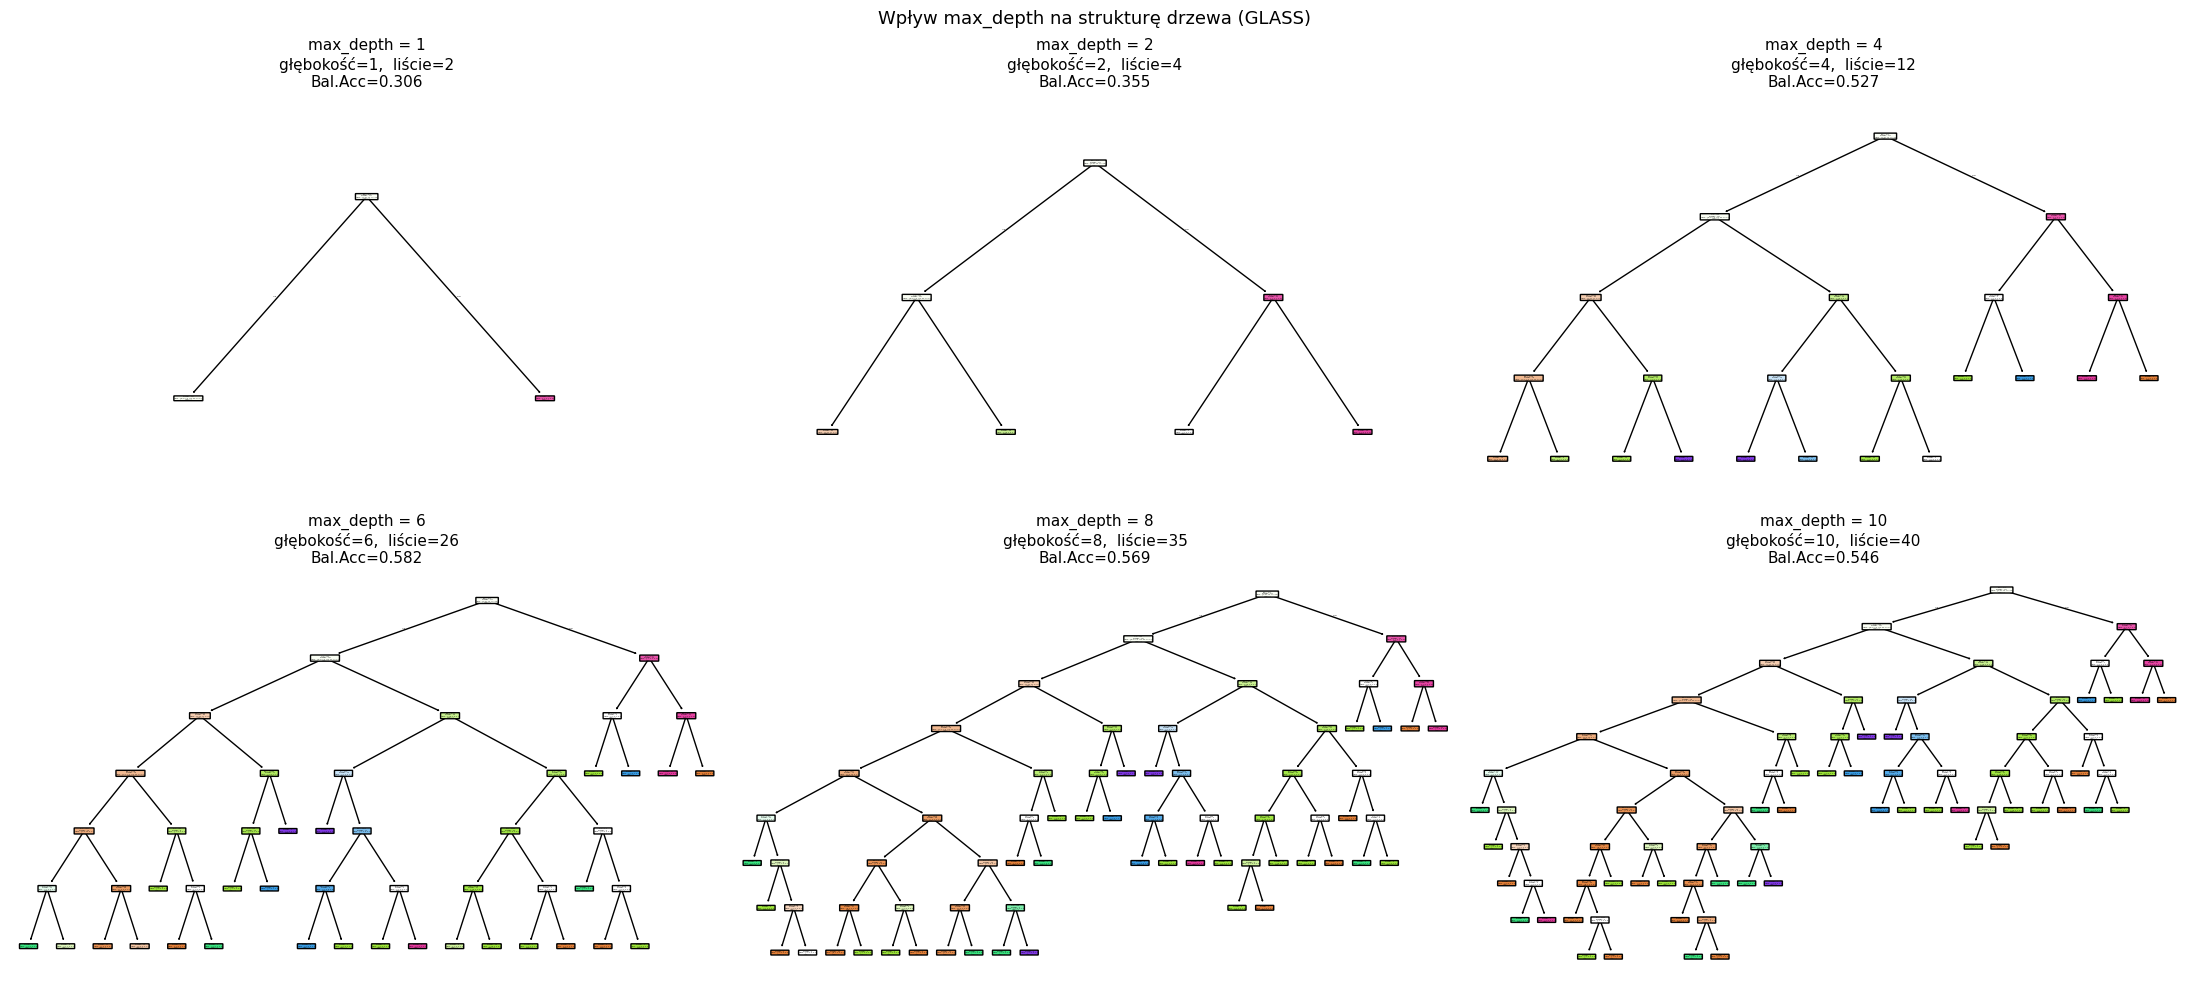

In [143]:
depth_values_vis = np.linspace(1, 10, 6, dtype=int)
depth_values_vis = np.clip(depth_values_vis, 1, clf_default.get_depth())

fig, axes = plt.subplots(2, 3, figsize=(22, 10))

for ax, d in zip(axes.flatten(), depth_values_vis):
    clf = DecisionTreeClassifier(max_depth=d)
    clf.fit(X_train, y_train)
    yp  = clf.predict(X_test)
    acc = balanced_accuracy_score(y_test, yp)
    rec = recall_score(y_test, yp, average='macro', zero_division=0)

    plot_tree(
        clf,
        feature_names=feature_names,
        class_names=class_names,
        filled=True,
        rounded=True,
        fontsize=1,
        ax=ax,
        impurity=False,
        proportion=False,
    )
    ax.set_title(
        f'max_depth = {d}\n'
        f'głębokość={clf.get_depth()},  liście={clf.get_n_leaves()}\n'
        f'Bal.Acc={acc:.3f}',
        fontsize=11
    )

plt.suptitle('Wpływ max_depth na strukturę drzewa (GLASS)', fontsize=13)
plt.tight_layout()
plt.show()

### 3.2 `min_samples_leaf` — minimalna liczba próbek w liściu



min_samples_leaf sweep:   0%|          | 0/30 [00:00<?, ?it/s]

Najlepsze min_samples_leaf (wg CV): 5, CV balanced acc=0.6536


,train_bacc,test_bacc,cv_mean,cv_std,train_prec,test_prec,n_leaves,actual_depth
min_samples_leaf,,,,,,,,
1,1.0000,0.5571,0.5612,0.1049,1.0000,0.5993,40,10
2,0.8576,0.5810,0.6432,0.1473,0.9483,0.6211,31,9
3,0.8310,0.5802,0.6250,0.1347,0.9121,0.6663,27,9
4,0.7851,0.5365,0.5856,0.1204,0.9149,0.6759,24,9
5,0.7420,0.5643,0.6536,0.1151,0.8637,0.6812,20,8
6,0.7624,0.5587,0.6314,0.0613,0.7871,0.5083,17,8
7,0.7386,0.7095,0.5155,0.0864,0.7543,0.6833,15,8
8,0.7219,0.7095,0.4403,0.1117,0.7371,0.6972,15,8
9,0.6307,0.6373,0.5139,0.0551,0.5815,0.5682,13,7


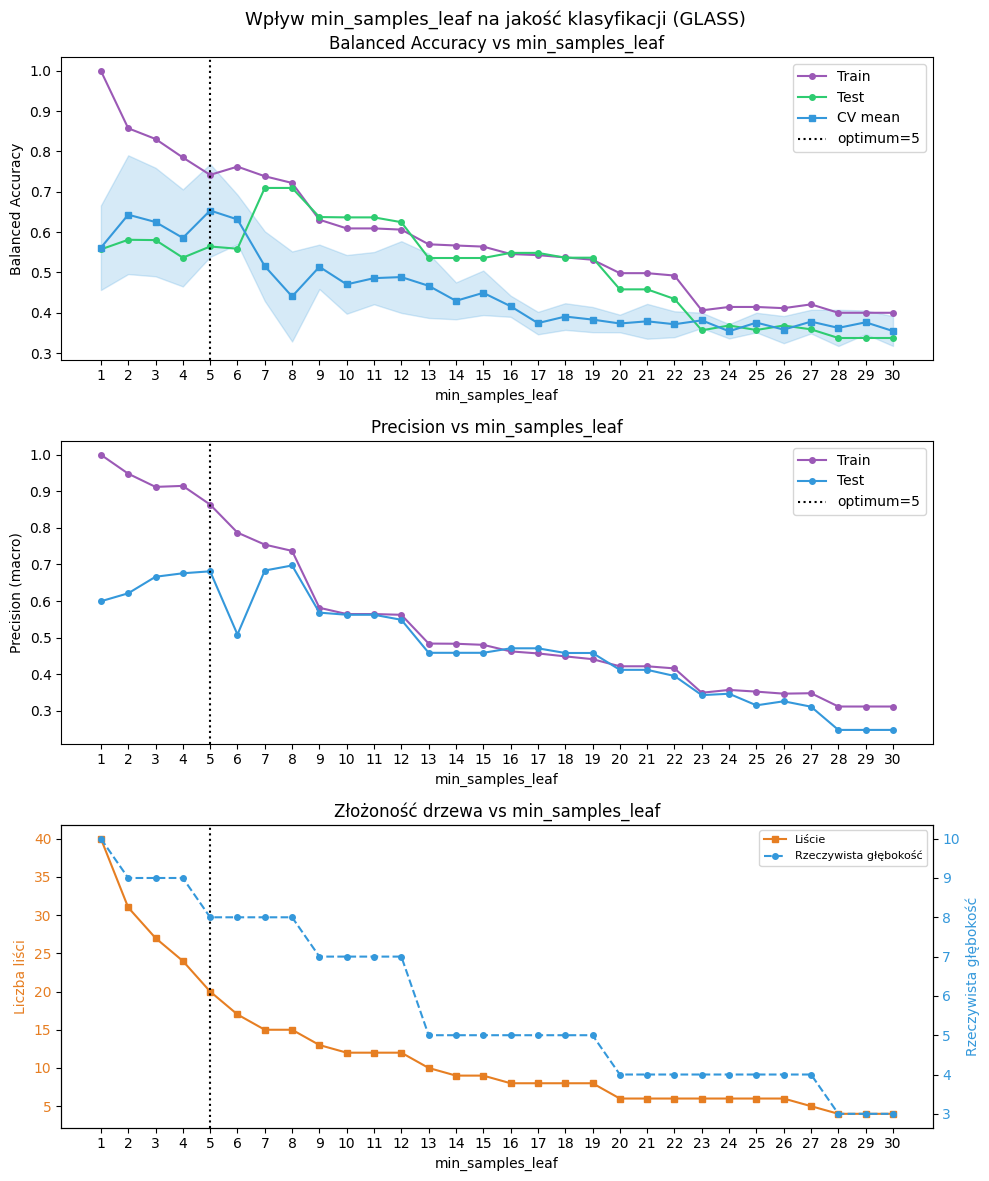

In [151]:
min_samples_values = list(range(1, 31))
leaf_results = []

skf = StratifiedKFold(n_splits=5, shuffle=True)

for ms in tqdm(min_samples_values, desc='min_samples_leaf sweep'):
    clf = DecisionTreeClassifier(min_samples_leaf=ms)
    clf.fit(X_train, y_train)
    yp_tr = clf.predict(X_train)
    yp_te = clf.predict(X_test)
    cv_scores = cross_val_score(clf, X_train, y_train, cv=skf, scoring='balanced_accuracy')

    leaf_results.append({
        'min_samples_leaf': ms,
        'actual_depth': clf.get_depth(),
        'train_bacc':   balanced_accuracy_score(y_train, yp_tr),
        'test_bacc':    balanced_accuracy_score(y_test, yp_te),
        'cv_mean':      cv_scores.mean(),
        'cv_std':       cv_scores.std(),
        'train_prec':   precision_score(y_train, yp_tr, average='macro', zero_division=0),
        'test_prec':    precision_score(y_test, yp_te, average='macro', zero_division=0),
        'n_leaves':     clf.get_n_leaves(),
    })

df_leaf = pd.DataFrame(leaf_results).set_index('min_samples_leaf')
best_ms = int(df_leaf['cv_mean'].idxmax())
print(f'Najlepsze min_samples_leaf (wg CV): {best_ms}, CV balanced acc={df_leaf.loc[best_ms, "cv_mean"]:.4f}')

display(df_leaf[['train_bacc', 'test_bacc', 'cv_mean', 'cv_std',
                   'train_prec', 'test_prec',
                   'n_leaves', 'actual_depth']].round(4))

fig, axes = plt.subplots(3, 1, figsize=(10, 12))

# 1) Balanced Accuracy: train / test / CV
axes[0].plot(df_leaf.index, df_leaf['train_bacc'], color='#9b59b6', marker='o', markersize=4, label='Train')
axes[0].plot(df_leaf.index, df_leaf['test_bacc'],  color='#2ecc71', marker='o', markersize=4, label='Test')
axes[0].plot(df_leaf.index, df_leaf['cv_mean'],    color='#3498db', marker='s', markersize=4, label='CV mean')
axes[0].fill_between(df_leaf.index,
                     df_leaf['cv_mean'] - df_leaf['cv_std'],
                     df_leaf['cv_mean'] + df_leaf['cv_std'],
                     alpha=0.2, color='#3498db')
axes[0].axvline(best_ms, color='black', linestyle=':', label=f'optimum={best_ms}')
axes[0].set_ylabel('Balanced Accuracy')
axes[0].set_xlabel('min_samples_leaf')
axes[0].set_title('Balanced Accuracy vs min_samples_leaf')
axes[0].set_xticks(df_leaf.index)
axes[0].legend()

# 2) Precision
axes[1].plot(df_leaf.index, df_leaf['train_prec'], color='#9b59b6', marker='o', markersize=4, label='Train')
axes[1].plot(df_leaf.index, df_leaf['test_prec'],  color='#3498db', marker='o', markersize=4, label='Test')
axes[1].axvline(best_ms, color='black', linestyle=':', label=f'optimum={best_ms}')
axes[1].set_ylabel('Precision (macro)')
axes[1].set_xlabel('min_samples_leaf')
axes[1].set_title('Precision vs min_samples_leaf')
axes[1].set_xticks(df_leaf.index)
axes[1].legend()

# 3) Złożoność + rzeczywista głębokość
axes[2].plot(df_leaf.index, df_leaf['n_leaves'], color='#e67e22', marker='s', markersize=4, label='Liście')
axes[2].axvline(best_ms, color='black', linestyle=':')
axes[2].set_ylabel('Liczba liści', color='#e67e22')
axes[2].tick_params(axis='y', labelcolor='#e67e22')
axes[2].set_xlabel('min_samples_leaf')
axes[2].set_title('Złożoność drzewa vs min_samples_leaf')
axes[2].set_xticks(df_leaf.index)

ax_act = axes[2].twinx()
ax_act.plot(df_leaf.index, df_leaf['actual_depth'], color='#3498db', marker='o', markersize=4, linestyle='--', label='Rzeczywista głębokość')
ax_act.set_ylabel('Rzeczywista głębokość', color='#3498db')
ax_act.tick_params(axis='y', labelcolor='#3498db')

lines1, labels1 = axes[2].get_legend_handles_labels()
lines2, labels2 = ax_act.get_legend_handles_labels()
axes[2].legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.suptitle('Wpływ min_samples_leaf na jakość klasyfikacji (GLASS)', fontsize=13)
plt.tight_layout()
plt.show()

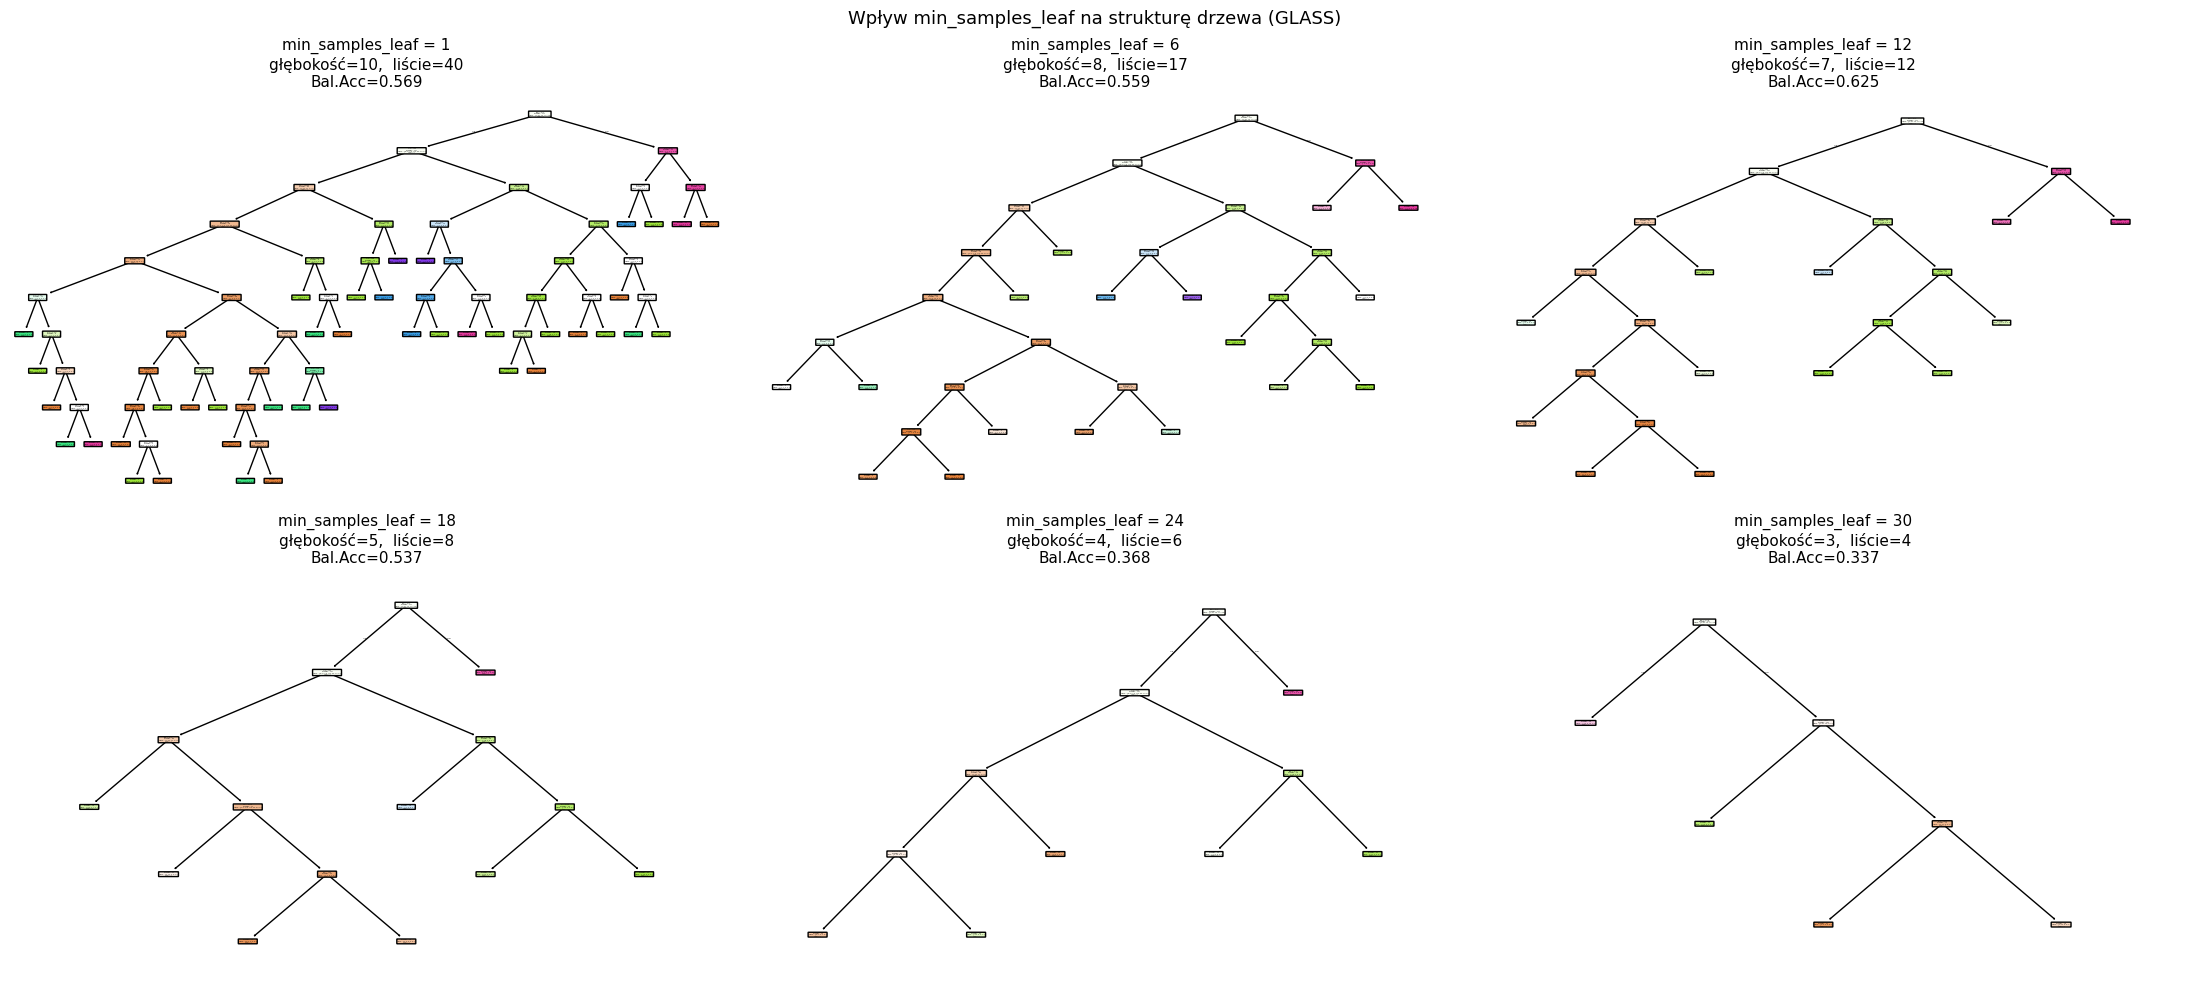

In [153]:
min_samples_values_vis = np.linspace(1, 30, 6, dtype=int)

fig, axes = plt.subplots(2, 3, figsize=(22, 10))

for ax, ms in zip(axes.flatten(), min_samples_values_vis):
    clf = DecisionTreeClassifier(min_samples_leaf=ms)
    clf.fit(X_train, y_train)
    yp  = clf.predict(X_test)
    acc = balanced_accuracy_score(y_test, yp)
    rec = recall_score(y_test, yp, average='macro', zero_division=0)

    plot_tree(
        clf,
        feature_names=feature_names,
        class_names=class_names,
        filled=True,
        rounded=True,
        fontsize=1,
        ax=ax,
        impurity=False,
        proportion=False,
    )
    ax.set_title(
        f'min_samples_leaf = {ms}\n'
        f'głębokość={clf.get_depth()},  liście={clf.get_n_leaves()}\n'
        f'Bal.Acc={acc:.3f}',
        fontsize=11
    )

plt.suptitle('Wpływ min_samples_leaf na strukturę drzewa (GLASS)', fontsize=13)
plt.tight_layout()
plt.show()

### 3.3 Przycinanie drzewa — `ccp_alpha` (Cost-Complexity Pruning)

Liczba kroków pruning path: 31
Zakres ccp_alpha: [0.000000, 0.076951]


ccp_alpha sweep:   0%|          | 0/31 [00:00<?, ?it/s]

Najlepsza ccp_alpha (wg CV): 0.008772, CV balanced acc=0.7161
Wynikowe drzewo: głębokość=8, liście=26


,train_bacc,test_bacc,cv_mean,cv_std,train_prec,test_prec,n_leaves,depth
0,1.0000,0.5579,0.5985,0.1167,1.0000,0.5495,40,10
1,0.9881,0.5579,0.6077,0.0429,0.9971,0.5708,38,10
2,0.9821,0.5579,0.5994,0.0702,0.9917,0.5495,34,10
3,0.9794,0.5690,0.6875,0.0868,0.9887,0.5619,32,9
4,0.9363,0.5690,0.5985,0.1028,0.9680,0.6314,28,8
5,0.9363,0.5690,0.6714,0.0462,0.9680,0.6028,28,8
6,0.9363,0.5690,0.6618,0.0660,0.9680,0.6028,28,8
7,0.9363,0.5690,0.5895,0.1236,0.9680,0.6314,28,8
8,0.9006,0.5690,0.7161,0.1114,0.9616,0.6097,26,8
9,0.9006,0.5690,0.5620,0.1192,0.9616,0.6097,26,8


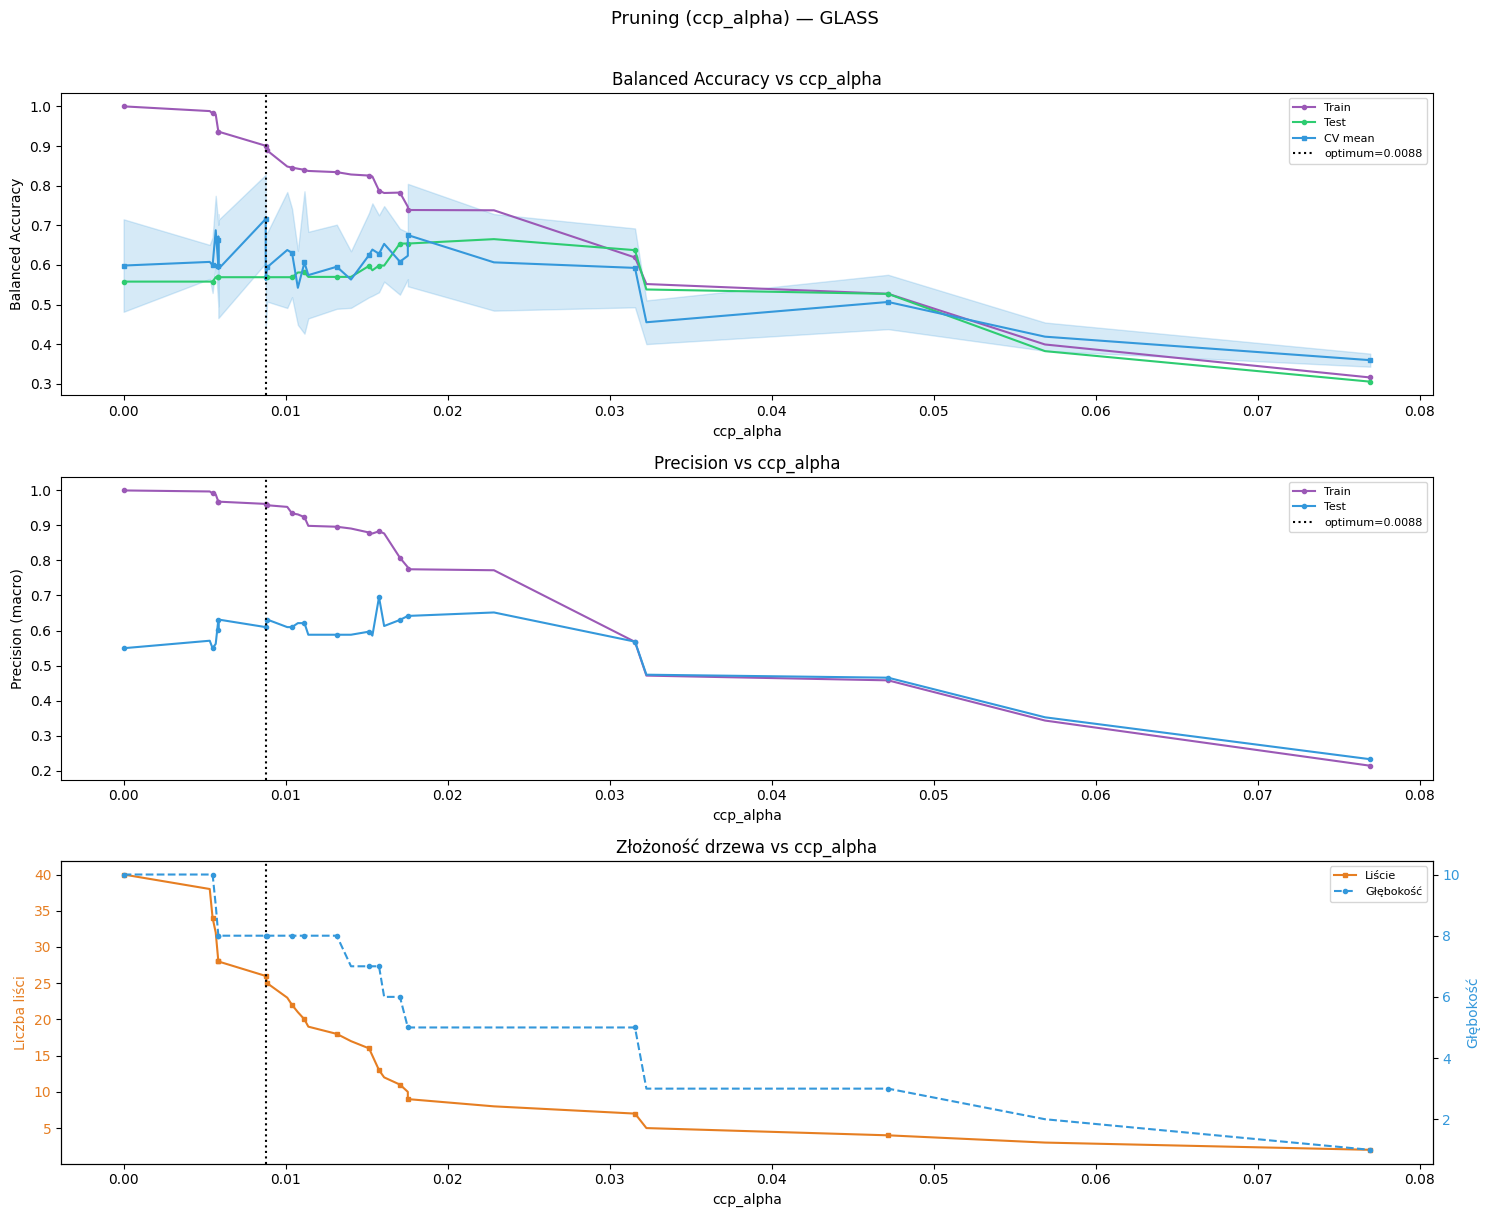

In [146]:
path = DecisionTreeClassifier().cost_complexity_pruning_path(X_train, y_train)
ccp_candidates = path.ccp_alphas[:-1]
step = max(1, len(ccp_candidates) // 8)

skf = StratifiedKFold(n_splits=5, shuffle=True)

print(f'Liczba kroków pruning path: {len(ccp_candidates)}')
print(f'Zakres ccp_alpha: [{ccp_candidates.min():.6f}, {ccp_candidates.max():.6f}]')

alpha_results = []
for alpha in tqdm(ccp_candidates, desc='ccp_alpha sweep'):
    clf = DecisionTreeClassifier(ccp_alpha=alpha)
    clf.fit(X_train, y_train)
    yp_tr = clf.predict(X_train)
    yp_te = clf.predict(X_test)
    cv_scores = cross_val_score(clf, X_train, y_train, cv=skf, scoring='balanced_accuracy')

    alpha_results.append({
        'ccp_alpha':   alpha,
        'depth':       clf.get_depth(),
        'train_bacc':  balanced_accuracy_score(y_train, yp_tr),
        'test_bacc':   balanced_accuracy_score(y_test, yp_te),
        'cv_mean':     cv_scores.mean(),
        'cv_std':      cv_scores.std(),
        'train_prec':  precision_score(y_train, yp_tr, average='macro', zero_division=0),
        'test_prec':   precision_score(y_test, yp_te, average='macro', zero_division=0),
        'n_leaves':    clf.get_n_leaves(),
    })

df_alpha = pd.DataFrame(alpha_results)
best_alpha_idx = df_alpha['cv_mean'].idxmax()
best_row       = df_alpha.loc[best_alpha_idx]
best_alpha     = float(best_row['ccp_alpha'])

print(f'Najlepsza ccp_alpha (wg CV): {best_alpha:.6f}, CV balanced acc={best_row["cv_mean"]:.4f}')
print(f'Wynikowe drzewo: głębokość={int(best_row["depth"])}, liście={int(best_row["n_leaves"])}')

n_points  = len(df_alpha)
markevery = max(1, n_points // 15)

display(df_alpha[['train_bacc', 'test_bacc', 'cv_mean', 'cv_std',
                   'train_prec', 'test_prec',
                   'n_leaves', 'depth']].round(4))

fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# 1) Balanced Accuracy: train / test / CV
axes[0].plot(df_alpha['ccp_alpha'], df_alpha['train_bacc'], color='#9b59b6', linewidth=1.5, marker='o', markersize=3, markevery=markevery, label='Train')
axes[0].plot(df_alpha['ccp_alpha'], df_alpha['test_bacc'],  color='#2ecc71', linewidth=1.5, marker='o', markersize=3, markevery=markevery, label='Test')
axes[0].plot(df_alpha['ccp_alpha'], df_alpha['cv_mean'],    color='#3498db', linewidth=1.5, marker='s', markersize=3, markevery=markevery, label='CV mean')
axes[0].fill_between(df_alpha['ccp_alpha'],
                     df_alpha['cv_mean'] - df_alpha['cv_std'],
                     df_alpha['cv_mean'] + df_alpha['cv_std'],
                     alpha=0.2, color='#3498db')
axes[0].axvline(best_alpha, color='black', linestyle=':', label=f'optimum={best_alpha:.4f}')
axes[0].set_ylabel('Balanced Accuracy')
axes[0].set_xlabel('ccp_alpha')
axes[0].set_title('Balanced Accuracy vs ccp_alpha')
axes[0].legend(fontsize=8)

# 2) Precision
axes[1].plot(df_alpha['ccp_alpha'], df_alpha['train_prec'], color='#9b59b6', linewidth=1.5, marker='o', markersize=3, markevery=markevery, label='Train')
axes[1].plot(df_alpha['ccp_alpha'], df_alpha['test_prec'],  color='#3498db', linewidth=1.5, marker='o', markersize=3, markevery=markevery, label='Test')
axes[1].axvline(best_alpha, color='black', linestyle=':', label=f'optimum={best_alpha:.4f}')
axes[1].set_ylabel('Precision (macro)')
axes[1].set_xlabel('ccp_alpha')
axes[1].set_title('Precision vs ccp_alpha')
axes[1].legend(fontsize=8)

# 3) Złożoność + głębokość
ax_leaves = axes[2]
ax_depth  = ax_leaves.twinx()
ax_leaves.plot(df_alpha['ccp_alpha'], df_alpha['n_leaves'], color='#e67e22', linewidth=1.5, marker='s', markersize=3, markevery=markevery, label='Liście')
ax_depth.plot(df_alpha['ccp_alpha'],  df_alpha['depth'],    color='#3498db', linewidth=1.5, marker='o', markersize=3, markevery=markevery, linestyle='--', label='Głębokość')
ax_leaves.axvline(best_alpha, color='black', linestyle=':')
ax_leaves.set_xlabel('ccp_alpha')
ax_leaves.set_ylabel('Liczba liści', color='#e67e22')
ax_depth.set_ylabel('Głębokość', color='#3498db')
ax_leaves.tick_params(axis='y', labelcolor='#e67e22')
ax_depth.tick_params(axis='y', labelcolor='#3498db')
ax_leaves.set_title('Złożoność drzewa vs ccp_alpha')
lines1, labels1 = ax_leaves.get_legend_handles_labels()
lines2, labels2 = ax_depth.get_legend_handles_labels()
ax_leaves.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.suptitle('Pruning (ccp_alpha) — GLASS', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

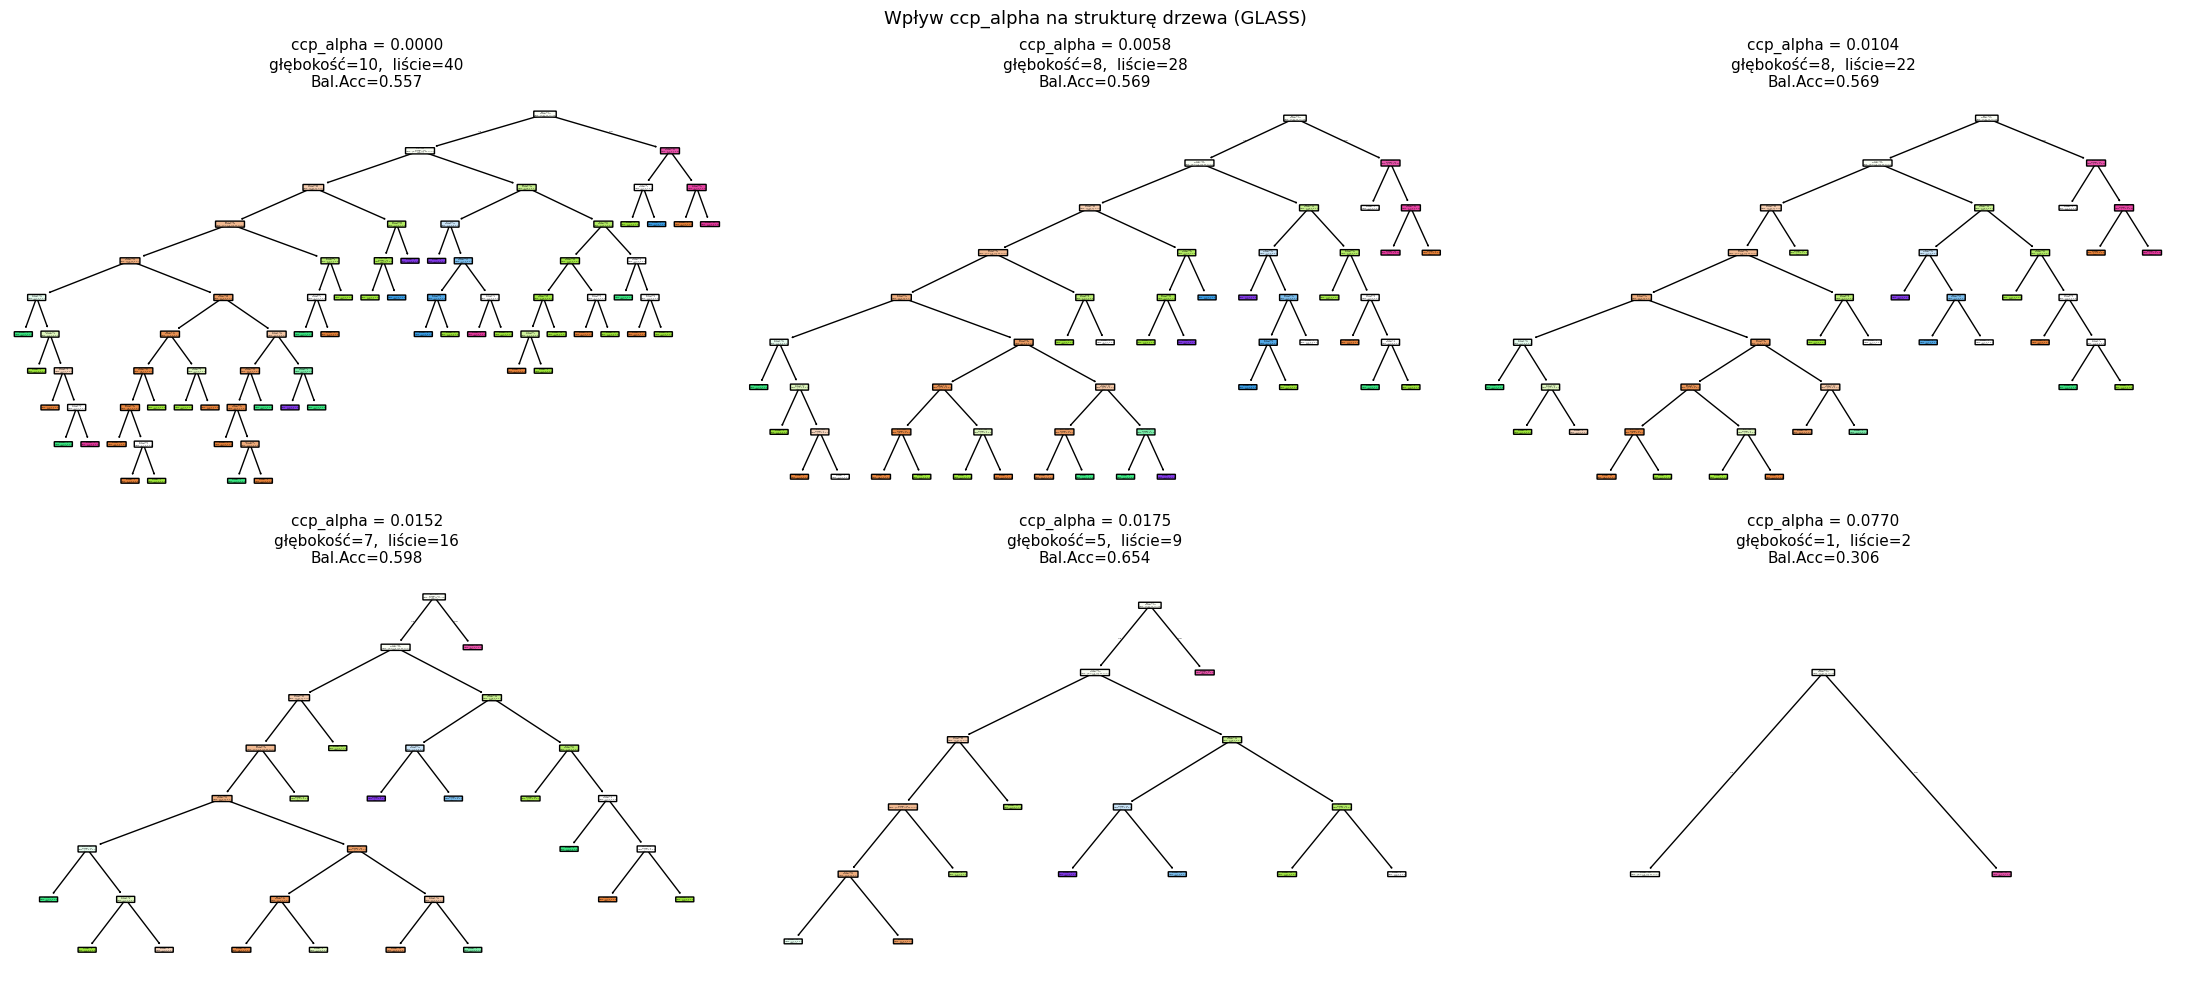

In [147]:
path = DecisionTreeClassifier().cost_complexity_pruning_path(X_train, y_train)
alphas = path.ccp_alphas[:-1]

indices = np.linspace(0, len(alphas) - 1, 6, dtype=int)
selected_alphas = alphas[indices]

fig, axes = plt.subplots(2, 3, figsize=(22, 10))

for ax, alpha in zip(axes.flatten(), selected_alphas):
    clf = DecisionTreeClassifier(ccp_alpha=alpha)
    clf.fit(X_train, y_train)
    yp = clf.predict(X_test)
    acc  = balanced_accuracy_score(y_test, yp)
    rec  = recall_score(y_test, yp, average='macro', zero_division=0)

    plot_tree(
        clf,
        feature_names=feature_names,
        class_names=class_names,
        filled=True,
        rounded=True,
        fontsize=1,
        ax=ax,
        impurity=False,
        proportion=False,
    )
    ax.set_title(
        f'ccp_alpha = {alpha:.4f}\n'
        f'głębokość={clf.get_depth()},  liście={clf.get_n_leaves()}\n'
        f'Bal.Acc={acc:.3f}',
        fontsize=11
    )

plt.suptitle('Wpływ ccp_alpha na strukturę drzewa (GLASS)', fontsize=13)
plt.tight_layout()
plt.show()

### 3.5 Wizualizacja wybranych drzew

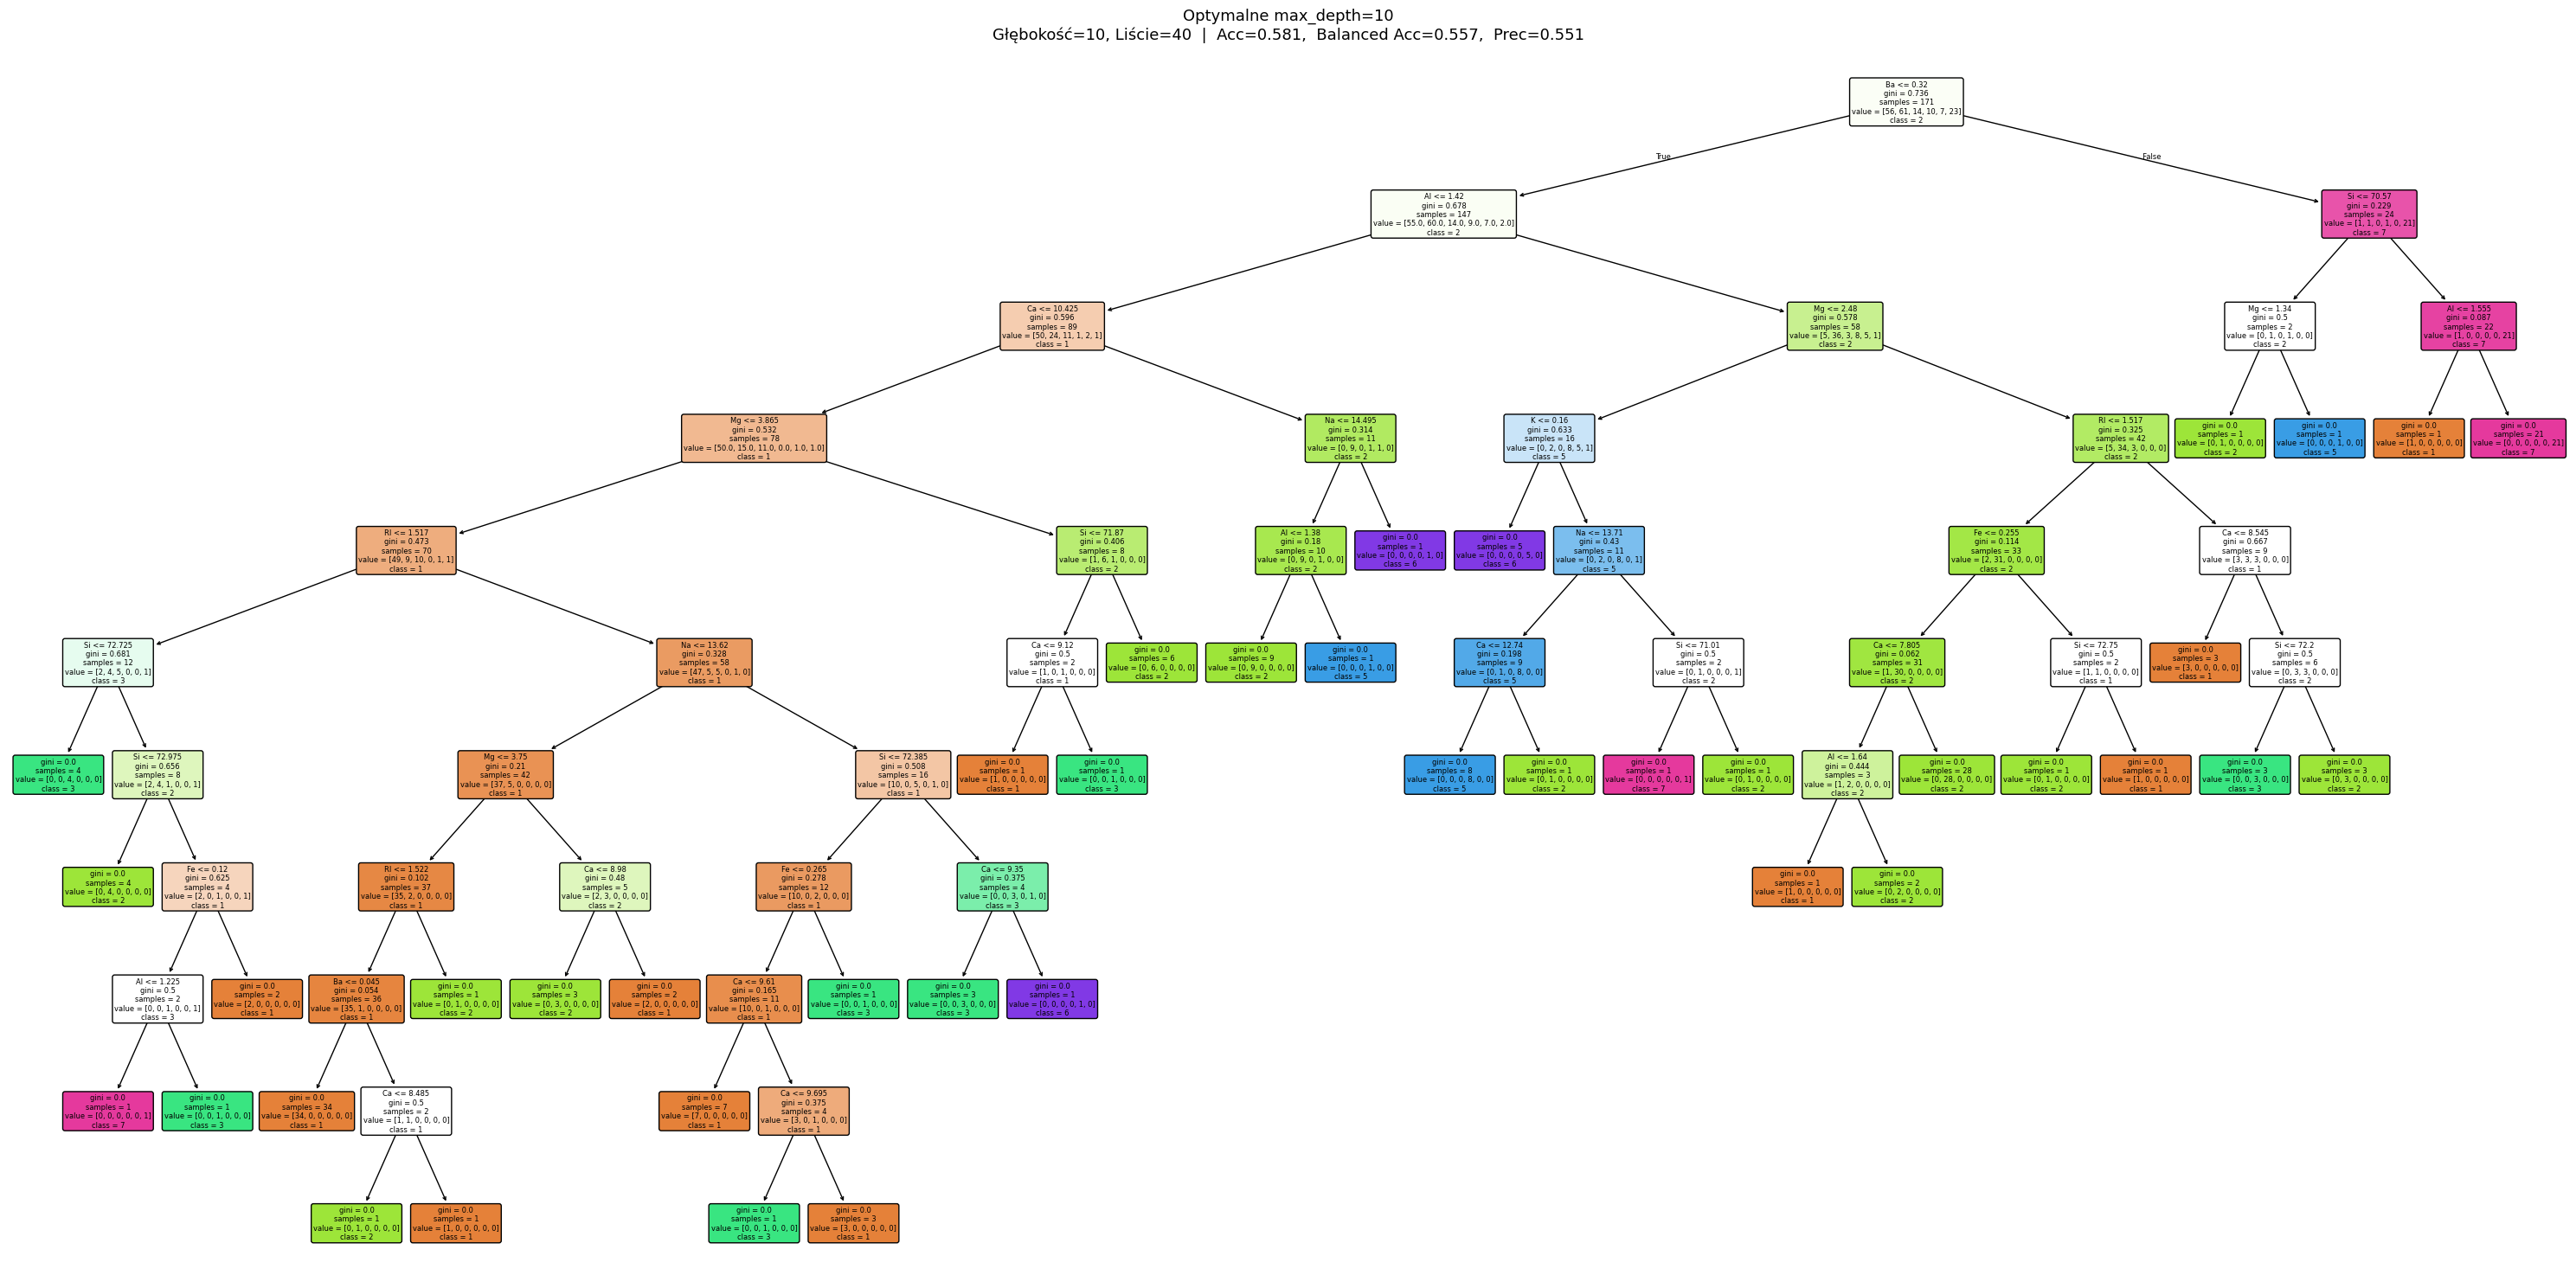

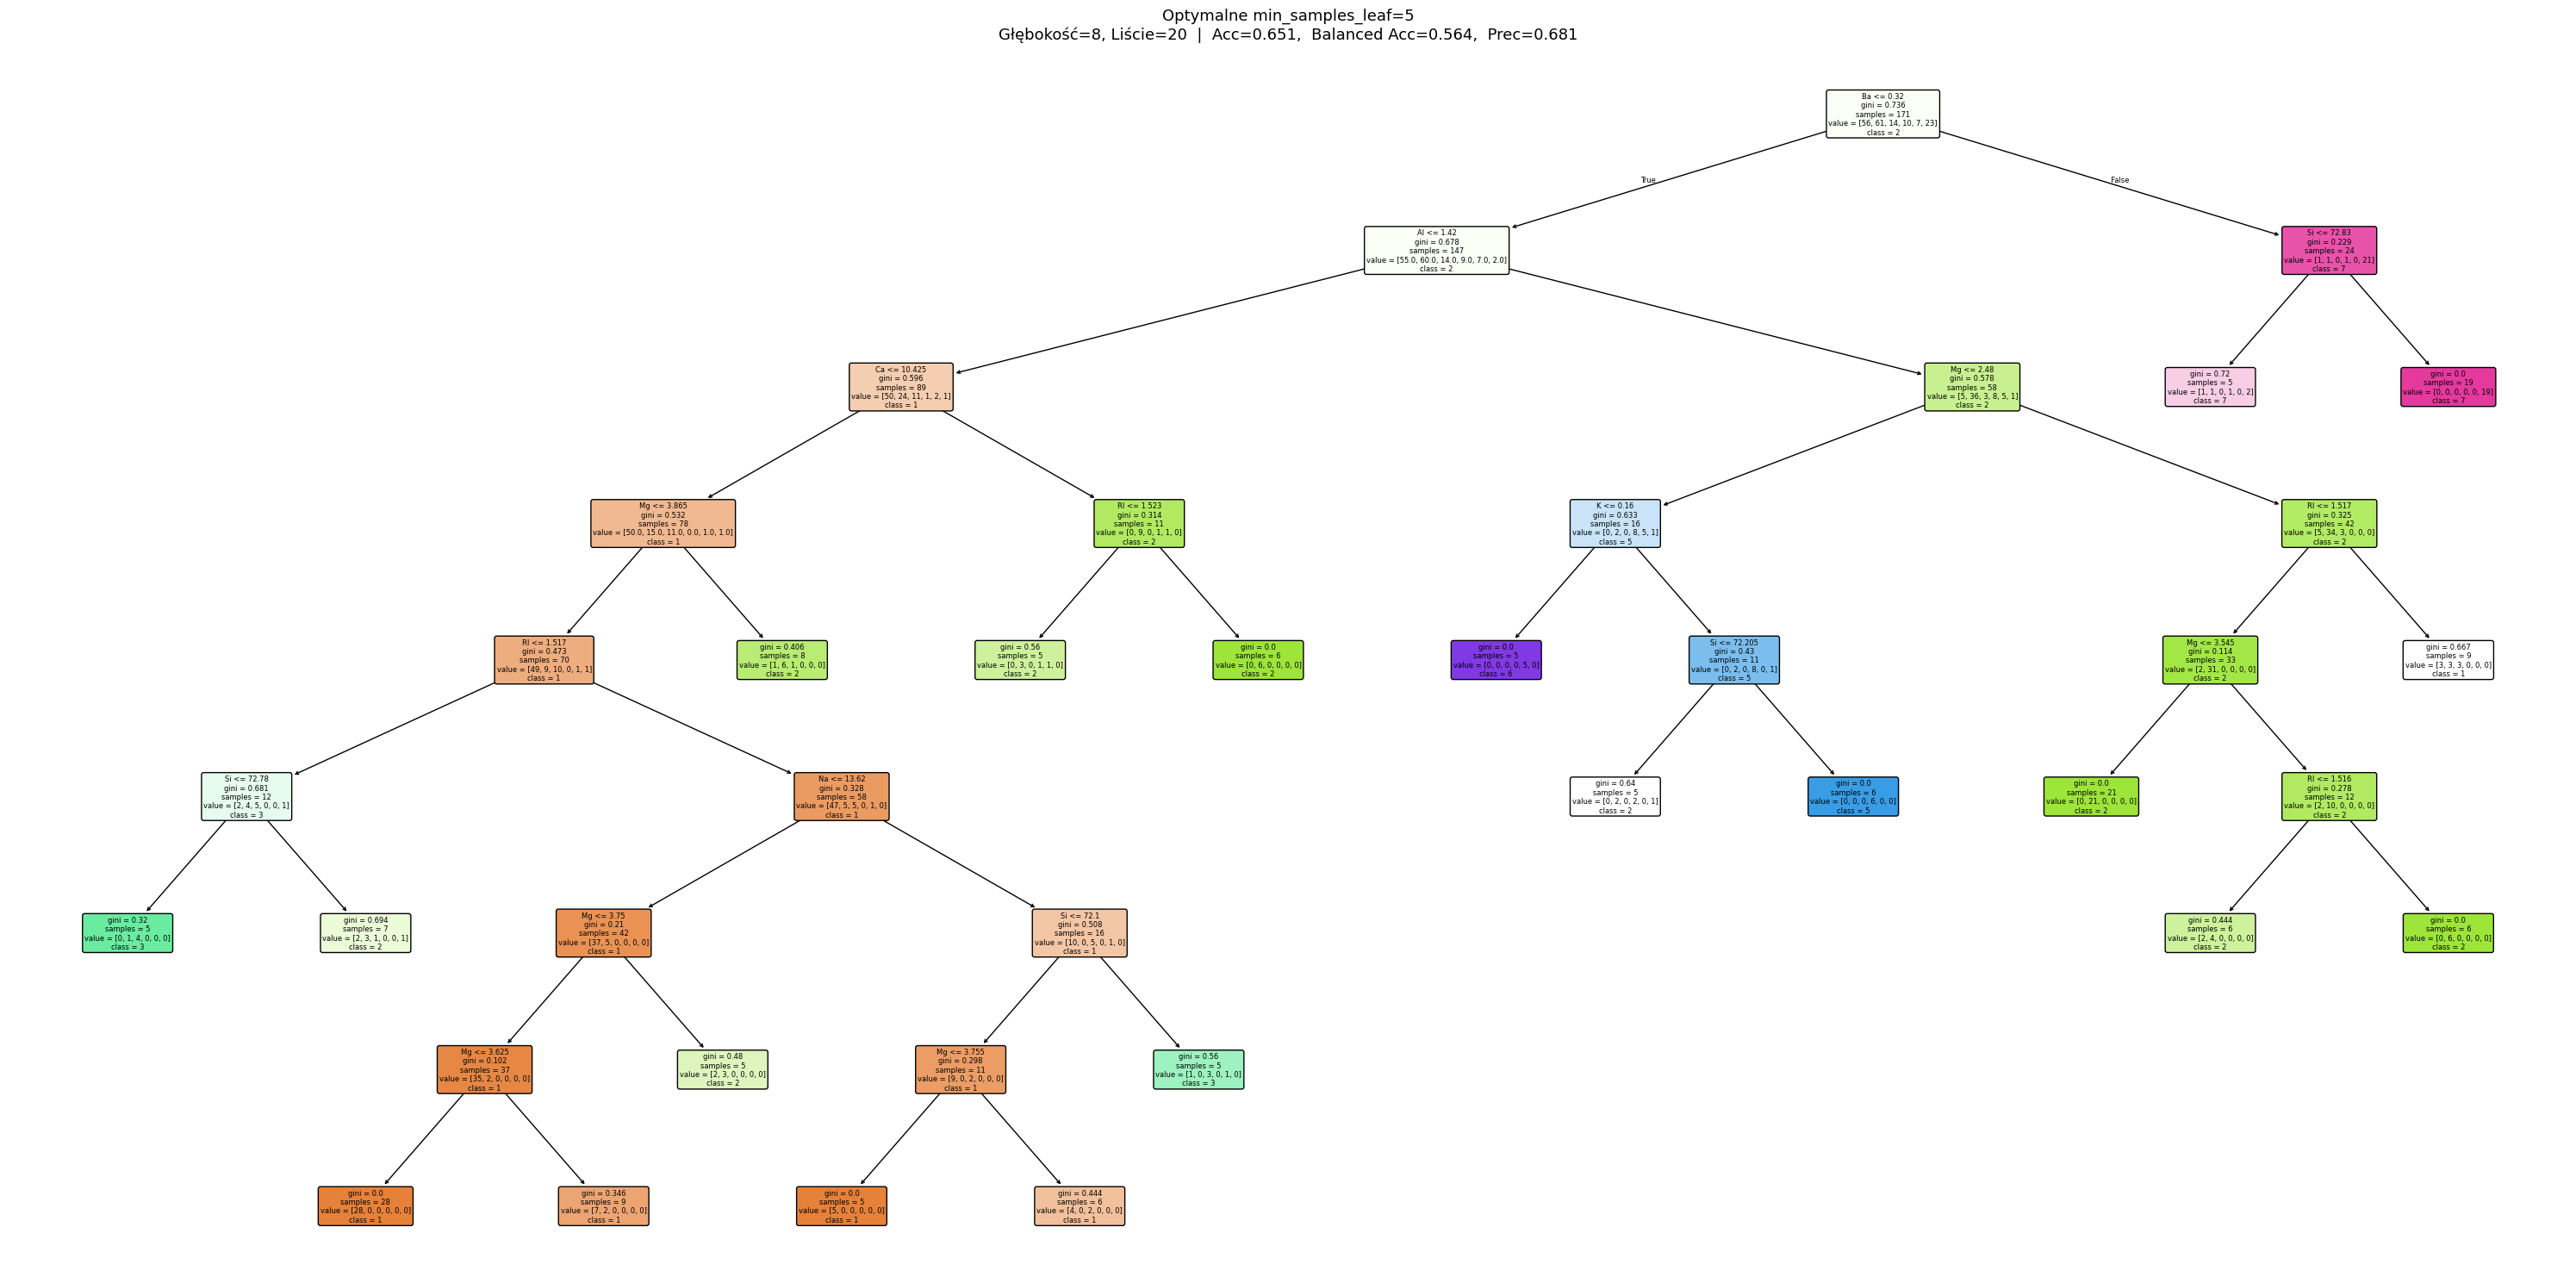

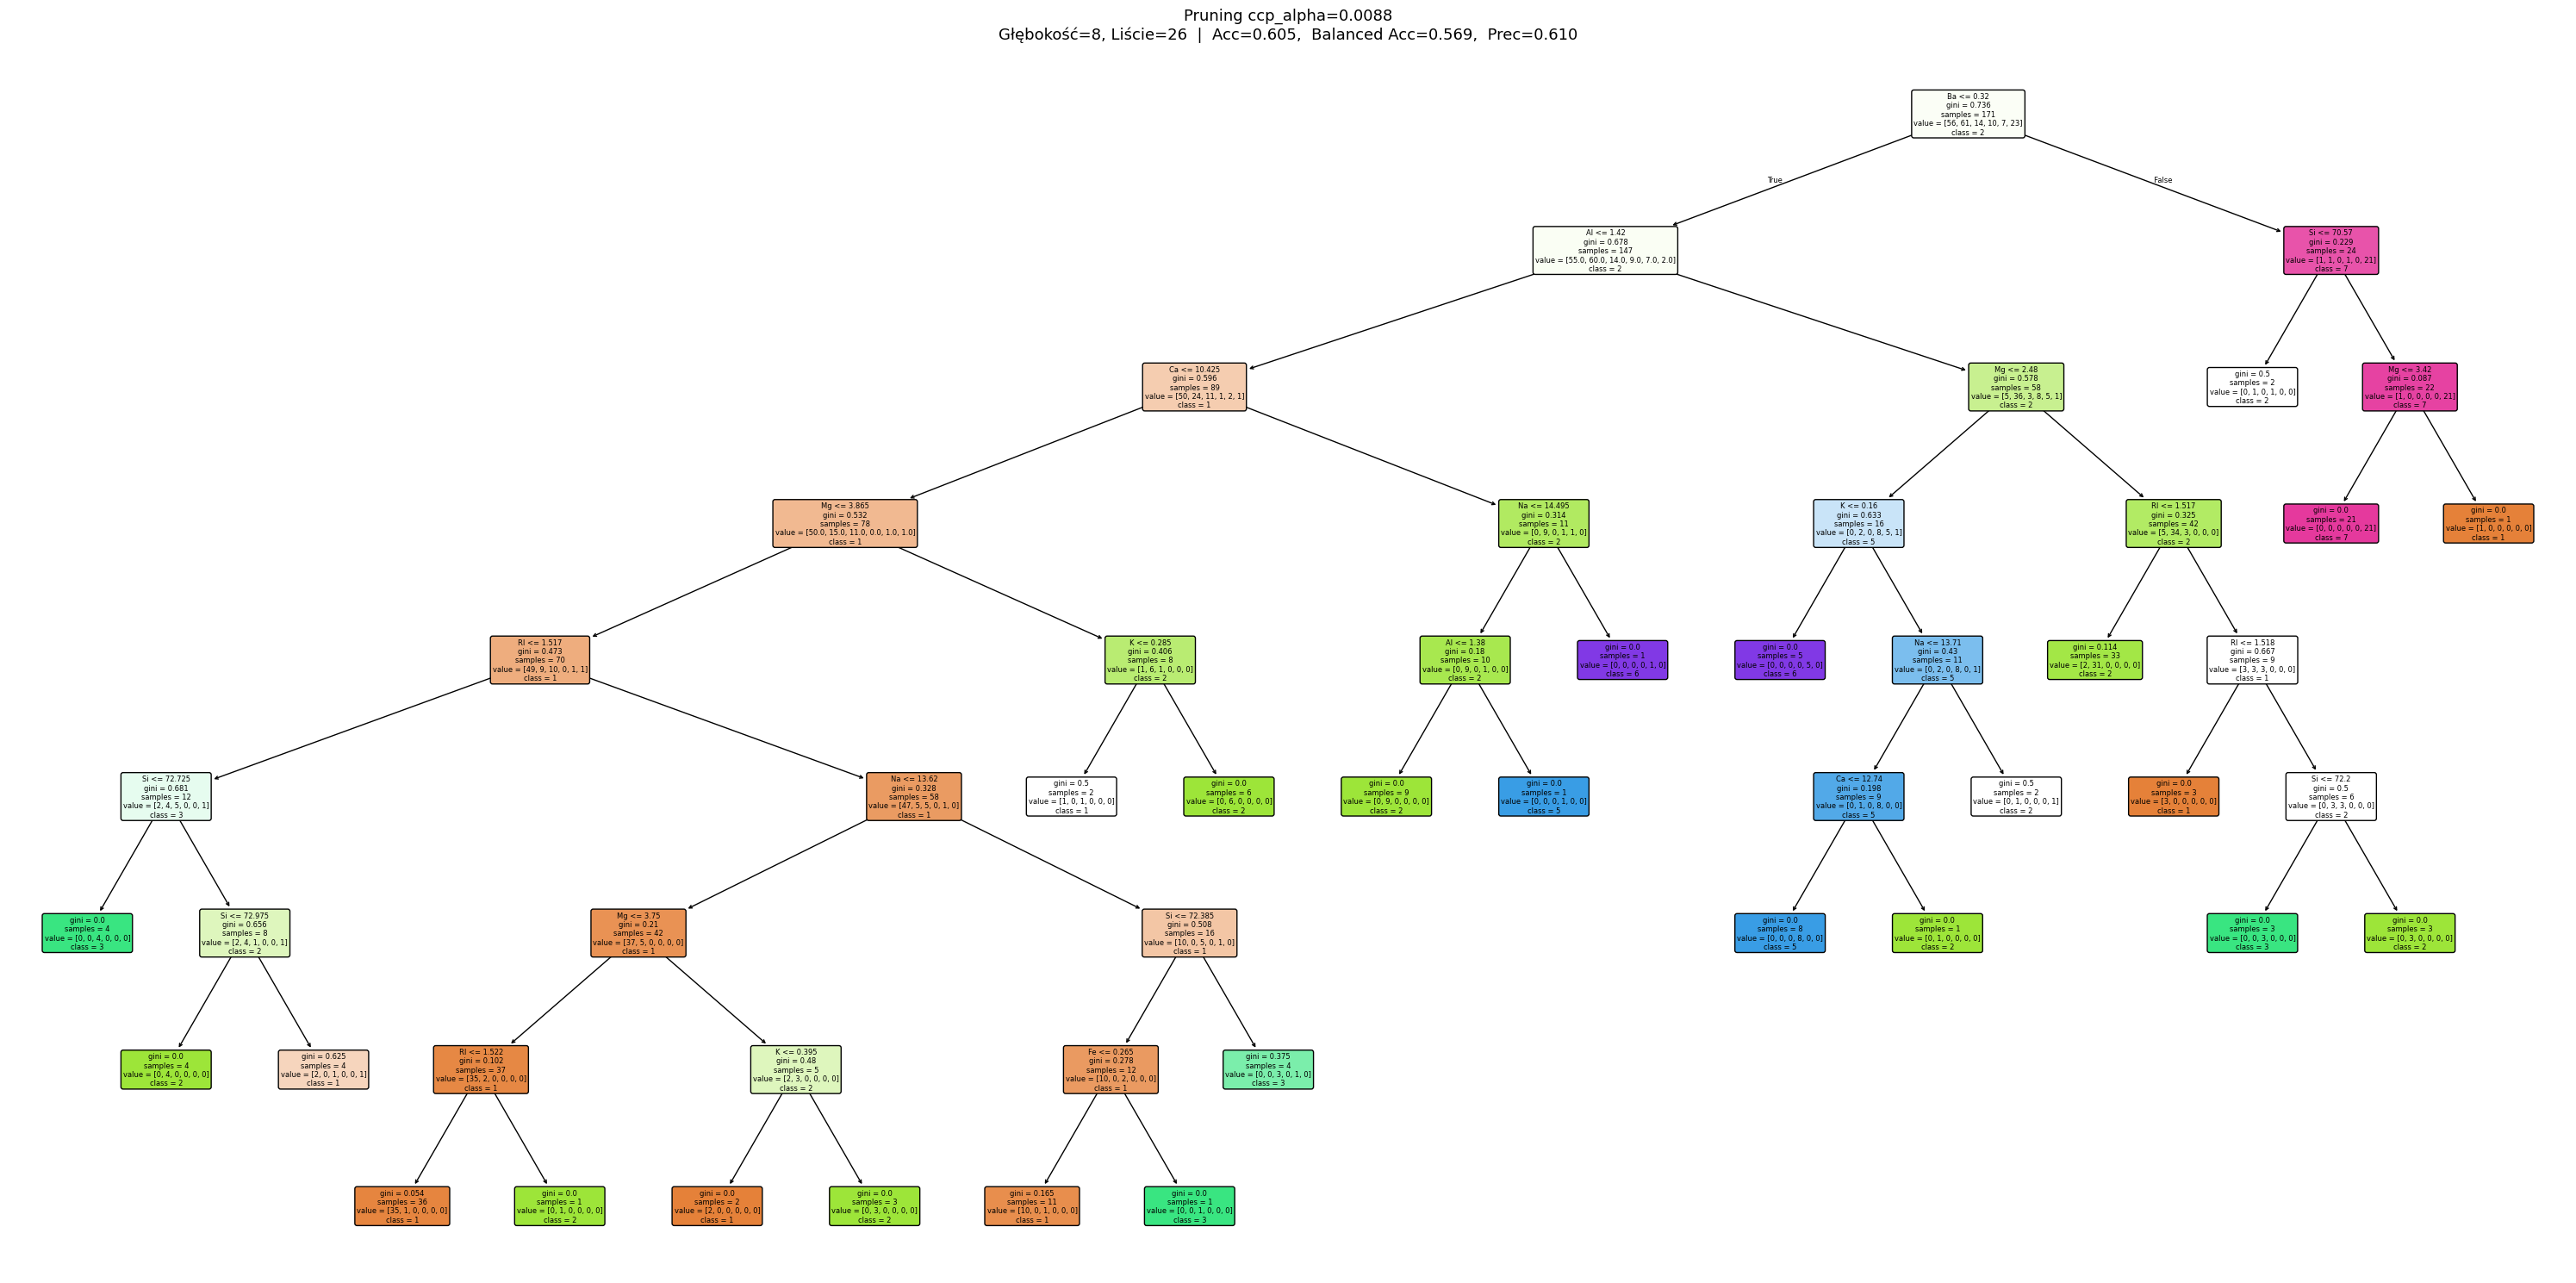

In [154]:
from sklearn.metrics import balanced_accuracy_score

tree_variants = [
    (f'Optymalne max_depth={best_depth}',        DecisionTreeClassifier(max_depth=best_depth)),
    (f'Optymalne min_samples_leaf={best_ms}',    DecisionTreeClassifier(min_samples_leaf=best_ms)),
    (f'Pruning ccp_alpha={best_alpha:.4f}',      DecisionTreeClassifier(ccp_alpha=best_alpha)),
]

for title, clf in tree_variants:
    clf.fit(X_train, y_train)
    yp   = clf.predict(X_test)
    acc  = accuracy_score(y_test, yp)
    bacc = balanced_accuracy_score(y_test, yp)
    prec = precision_score(y_test, yp, average='macro', zero_division=0)
    rec  = recall_score(y_test, yp, average='macro', zero_division=0)
    d    = clf.get_depth()
    nl   = clf.get_n_leaves()

    fig, ax = plt.subplots(figsize=(30, 15))
    plot_tree(clf, feature_names=feature_names, class_names=class_names,
              filled=True, rounded=True, fontsize=6, ax=ax)
    ax.set_title(
        f'{title}\n'
        f'Głębokość={d}, Liście={nl}  |  '
        f'Acc={acc:.3f},  Balanced Acc={bacc:.3f},  Prec={prec:.3f}',
        fontsize=13
    )
    plt.tight_layout()
    plt.show()

### 4. Walidacja krzyżowa: zwykła vs stratyfikowana

Metoda                     Mean      Std  Wyniki foldów
------------------------------------------------------------------------
KFold                    0.5736   0.1221  [0.4759 0.7919 0.5361 0.6111 0.453 ]
StratifiedKFold          0.6047   0.0737  [0.6994 0.6726 0.5627 0.5921 0.4968]


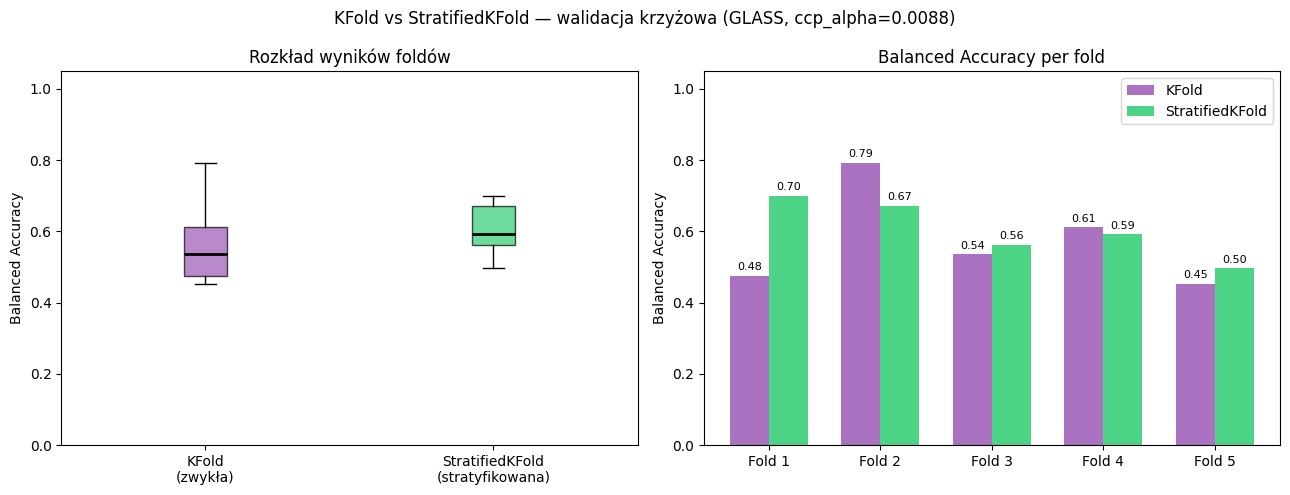

In [155]:
clf_cv = DecisionTreeClassifier(ccp_alpha=best_alpha)

kf  = KFold(n_splits=5, shuffle=True)
skf = StratifiedKFold(n_splits=5, shuffle=True)

scores_kf  = cross_val_score(clf_cv, X_glass, y_glass, cv=kf,  scoring='balanced_accuracy')
scores_skf = cross_val_score(clf_cv, X_glass, y_glass, cv=skf, scoring='balanced_accuracy')

print(f'{"Metoda":<22} {"Mean":>8} {"Std":>8}  Wyniki foldów')
print('-' * 72)
print(f'{"KFold":<22} {scores_kf.mean():>8.4f} {scores_kf.std():>8.4f}  {np.round(scores_kf, 4)}')
print(f'{"StratifiedKFold":<22} {scores_skf.mean():>8.4f} {scores_skf.std():>8.4f}  {np.round(scores_skf, 4)}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# boxplot
bp = axes[0].boxplot([scores_kf, scores_skf],
                     tick_labels=['KFold\n(zwykła)', 'StratifiedKFold\n(stratyfikowana)'],
                     patch_artist=True)
for patch, color in zip(bp['boxes'], ['#9b59b6', '#2ecc71']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for med in bp['medians']:
    med.set_color('black')
    med.set_linewidth(2)
axes[0].set_title('Rozkład wyników foldów')
axes[0].set_ylabel('Balanced Accuracy')
axes[0].set_ylim(0, 1.05)

# bar per fold
x = np.arange(5)
width = 0.35
fold_labels = [f'Fold {i+1}' for i in range(5)]
bars_kf  = axes[1].bar(x - width/2, scores_kf,  width, color='#9b59b6', alpha=0.85, label='KFold')
bars_skf = axes[1].bar(x + width/2, scores_skf, width, color='#2ecc71', alpha=0.85, label='StratifiedKFold')
for bars in [bars_kf, bars_skf]:
    for bar in bars:
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(fold_labels)
axes[1].set_title('Balanced Accuracy per fold')
axes[1].set_ylabel('Balanced Accuracy')
axes[1].set_ylim(0, 1.05)
axes[1].legend()

plt.suptitle(f'KFold vs StratifiedKFold — walidacja krzyżowa (GLASS, ccp_alpha={best_alpha:.4f})', fontsize=12)
plt.tight_layout()
plt.show()

KFold: best_alpha=0.011682, CV balanced_acc=0.7078
StratifiedKFold: best_alpha=0.007923, CV balanced_acc=0.7131

--- KFold — metryki per klasa (test) ---
Klasa       Precision     Recall    Support
------------------------------------------
1              0.8462     0.7857         14
2              0.7059     0.8000         15
3              0.3333     0.3333          3
5              1.0000     1.0000          3
6              1.0000     0.5000          2
7              1.0000     1.0000          6

--- StratifiedKFold — metryki per klasa (test) ---
Klasa       Precision     Recall    Support
------------------------------------------
1              0.9231     0.8571         14
2              0.8667     0.8667         15
3              0.5000     0.6667          3
5              1.0000     1.0000          3
6              1.0000     1.0000          2
7              1.0000     1.0000          6

--- Globalne metryki (test) ---
Metryka                      KFold    StratifiedKFold
-----

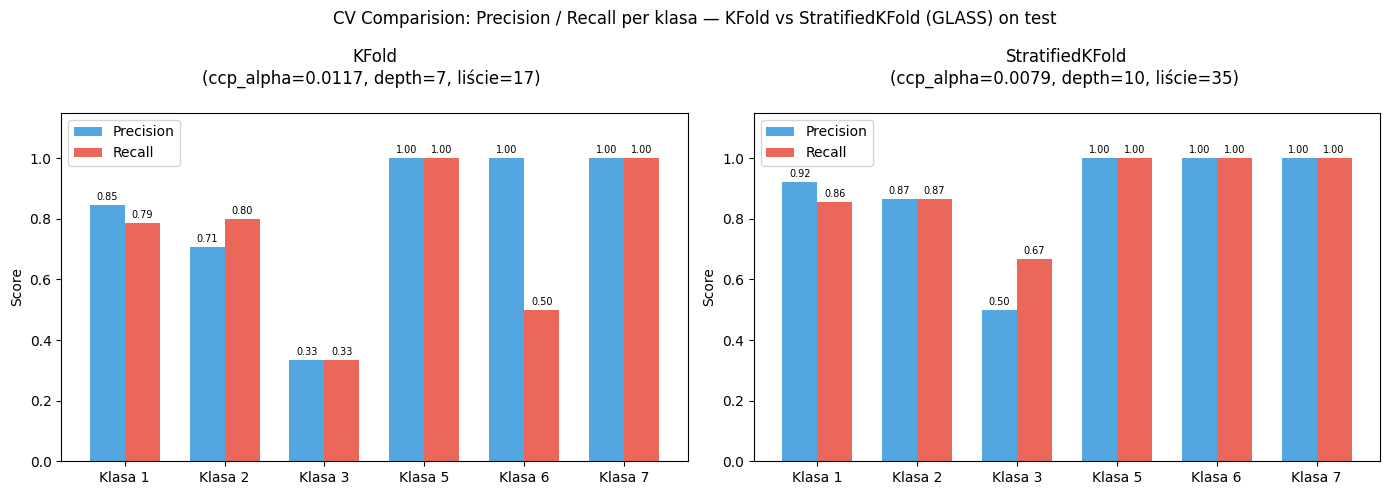

In [ ]:
path = DecisionTreeClassifier().cost_complexity_pruning_path(X_glass, y_glass)
ccp_candidates = path.ccp_alphas[:-1]
step = max(1, len(ccp_candidates) // 8)
ccp_grid = [0.0] + list(ccp_candidates[::step])

kf  = KFold(n_splits=5, shuffle=True)
skf = StratifiedKFold(n_splits=5, shuffle=True)

results_per_cv = {}
for cv_name, cv in [('KFold', kf), ('StratifiedKFold', skf)]:
    best_score, best_alpha_cv = -1, 0.0
    for alpha in ccp_grid:
        clf = DecisionTreeClassifier(ccp_alpha=alpha)
        scores = cross_val_score(clf, X_glass, y_glass, cv=cv, scoring='balanced_accuracy')
        if scores.mean() > best_score:
            best_score = scores.mean()
            best_alpha_cv = alpha

    clf_final = DecisionTreeClassifier(ccp_alpha=best_alpha_cv)
    clf_final.fit(X_train, y_train)
    yp = clf_final.predict(X_test)

    results_per_cv[cv_name] = {
        'best_alpha': best_alpha_cv,
        'cv_score':   best_score,
        'clf':        clf_final,
        'y_pred':     yp,
    }
    print(f'{cv_name}: best_alpha={best_alpha_cv:.6f}, CV balanced_acc={best_score:.4f}')



# --- metryki per klasa (print) ---
for cv_name, res in results_per_cv.items():
    print(f'\n--- {cv_name} — metryki per klasa (test) ---')
    report = classification_report(y_test, res['y_pred'], output_dict=True, zero_division=0)
    classes = [k for k in report if k not in ('accuracy', 'macro avg', 'weighted avg')]
    print(f'{"Klasa":<10} {"Precision":>10} {"Recall":>10} {"Support":>10}')
    print('-' * 42)
    for c in classes:
        r = report[c]
        print(f'{c:<10} {r["precision"]:>10.4f} {r["recall"]:>10.4f} {int(r["support"]):>10}')

# --- globalne metryki ---
print('\n--- Globalne metryki (test) ---')
print(f'{"Metryka":<15}', end='')
for cv_name in results_per_cv:
    print(f' {cv_name:>18}', end='')
print()
print('-' * 55)

for metric_name, fn, kw in [
    ('Accuracy',  accuracy_score,  {}),
    ('Bal.Acc',  balanced_accuracy_score, {}),
    ('Precision', precision_score, {'average': 'macro', 'zero_division': 0}),
    ('Recall',    recall_score,    {'average': 'macro', 'zero_division': 0}),
]:
    print(f'{metric_name:<15}', end='')
    for res in results_per_cv.values():
        val = fn(y_test, res['y_pred'], **kw)
        print(f' {val:>18.4f}', end='')
    print()


# --- metryki per klasa (wykres) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (cv_name, res) in zip(axes, results_per_cv.items()):
    report = classification_report(y_test, res['y_pred'], output_dict=True, zero_division=0)
    classes = [k for k in report if k not in ('accuracy', 'macro avg', 'weighted avg')]

    prec_vals = [report[c]['precision'] for c in classes]
    rec_vals  = [report[c]['recall']    for c in classes]

    x = np.arange(len(classes))
    width = 0.35
    bars_p = ax.bar(x - width/2, prec_vals, width, color='#3498db', alpha=0.85, label='Precision')
    bars_r = ax.bar(x + width/2, rec_vals,  width, color='#e74c3c', alpha=0.85, label='Balanced Accuracy')

    for bars in [bars_p, bars_r]:
        for bar in bars:
            if bar.get_height() > 0.02:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                        f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels([f'Klasa {c}' for c in classes])
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Score')
    ax.set_title(f'{cv_name}\n(ccp_alpha={res["best_alpha"]:.4f}, depth={res["clf"].get_depth()}, liście={res["clf"].get_n_leaves()}) \n ')
    ax.legend()

plt.suptitle('CV Comparision: Precision / Balanced Accuracy per klasa — KFold vs StratifiedKFold (GLASS) on test', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Zbiór Polish Companies Bankruptcy (PCB)


### 5.1 Wczytanie i preprocessing

In [113]:
print('Wczytywanie Polish Companies Bankruptcy (UCI id=365)...')
dataset = fetch_ucirepo(id=365)
X_raw = dataset.data.features
y_raw = dataset.data.targets

df_pcb = X_raw.copy()
df_pcb['class'] = y_raw['class'].values

print(f'Pełny zbiór: {df_pcb.shape}')
years = sorted(df_pcb['year'].unique())
print(f'Lata: {years}')

df4 = df_pcb[df_pcb['year'] == 4].drop(columns=['year', 'A37'])
feat_cols_pcb = [c for c in df4.columns if c != 'class']
df4 = df4[df4[feat_cols_pcb].isnull().sum(axis=1) <= 7].reset_index(drop=True)

X_pcb = df4[feat_cols_pcb]
y_pcb = df4['class'].astype(int)

print(f'Po filtracji (rok 4, maks. 7 braków): {df4.shape}')
print(f'Bankruci:  {y_pcb.sum()} ({100*y_pcb.mean():.1f}%)')
print(f'OK: {(y_pcb == 0).sum()} ({100*(1-y_pcb.mean()):.1f}%)')

X_pcb_train_raw, X_pcb_test_raw, y_pcb_train, y_pcb_test = train_test_split(
    X_pcb, y_pcb, test_size=0.2, stratify=y_pcb
)

imputer = SimpleImputer(strategy='median')
X_pcb_train = imputer.fit_transform(X_pcb_train_raw)
X_pcb_test  = imputer.transform(X_pcb_test_raw)

print(f'Train: {X_pcb_train.shape}  |  Test: {X_pcb_test.shape}')
print(f'Bankruci train: {y_pcb_train.sum()} ({100*y_pcb_train.mean():.1f}%)')

Wczytywanie Polish Companies Bankruptcy (UCI id=365)...
Pełny zbiór: (43405, 66)
Lata: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Po filtracji (rok 4, maks. 7 braków): (9719, 64)
Bankruci:  508 (5.2%)
OK: 9211 (94.8%)
Train: (7775, 63)  |  Test: (1944, 63)
Bankruci train: 406 (5.2%)


### 5.2 Drzewo decyzyjne — domyślne parametry (PCB)

Głębokość: 29, Liście: 290

Metryka            Train     Test
-----------------------------------
Accuracy          1.0000   0.9208
Precision         1.0000   0.2833
Recall            1.0000   0.3333
F1                1.0000   0.3063


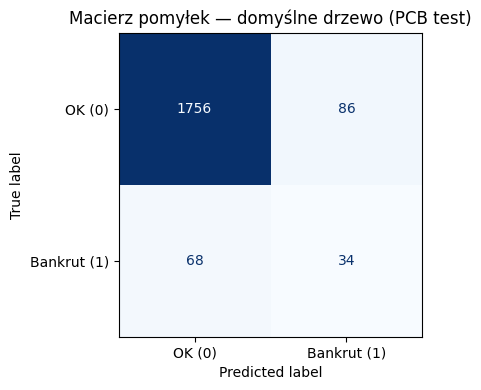

In [114]:
clf_pcb_default = DecisionTreeClassifier()
clf_pcb_default.fit(X_pcb_train, y_pcb_train)

y_pcb_train_pred = clf_pcb_default.predict(X_pcb_train)
y_pcb_test_pred  = clf_pcb_default.predict(X_pcb_test)

print(f'Głębokość: {clf_pcb_default.get_depth()}, Liście: {clf_pcb_default.get_n_leaves()}')
print()
print('{:<15} {:>8} {:>8}'.format('Metryka', 'Train', 'Test'))
print('-' * 35)
for name, tr, te in [
    ('Accuracy',  accuracy_score(y_pcb_train, y_pcb_train_pred),
                  accuracy_score(y_pcb_test,  y_pcb_test_pred)),
    ('Precision', precision_score(y_pcb_train, y_pcb_train_pred, zero_division=0),
                  precision_score(y_pcb_test,  y_pcb_test_pred,  zero_division=0)),
    ('Recall',    recall_score(y_pcb_train, y_pcb_train_pred, zero_division=0),
                  recall_score(y_pcb_test,  y_pcb_test_pred,  zero_division=0)),
    ('F1',        f1_score(y_pcb_train, y_pcb_train_pred, zero_division=0),
                  f1_score(y_pcb_test,  y_pcb_test_pred,  zero_division=0)),
]:
    print('{:<15} {:>8.4f} {:>8.4f}'.format(name, tr, te))

fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_pcb_test, y_pcb_test_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['OK (0)', 'Bankrut (1)'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Macierz pomyłek — domyślne drzewo (PCB test)')
plt.tight_layout()
plt.show()

### 5.3 Wpływ parametru `max_depth` na wyniki (PCB)

max_depth sweep (PCB):   0%|          | 0/49 [00:00<?, ?it/s]

Drzewo nasycone przy max_depth=30 (rzeczywista głębokość=29), przerywam sweep.
Najlepsza głębokość (wg CV recall): max_depth=28, CV recall=0.4091


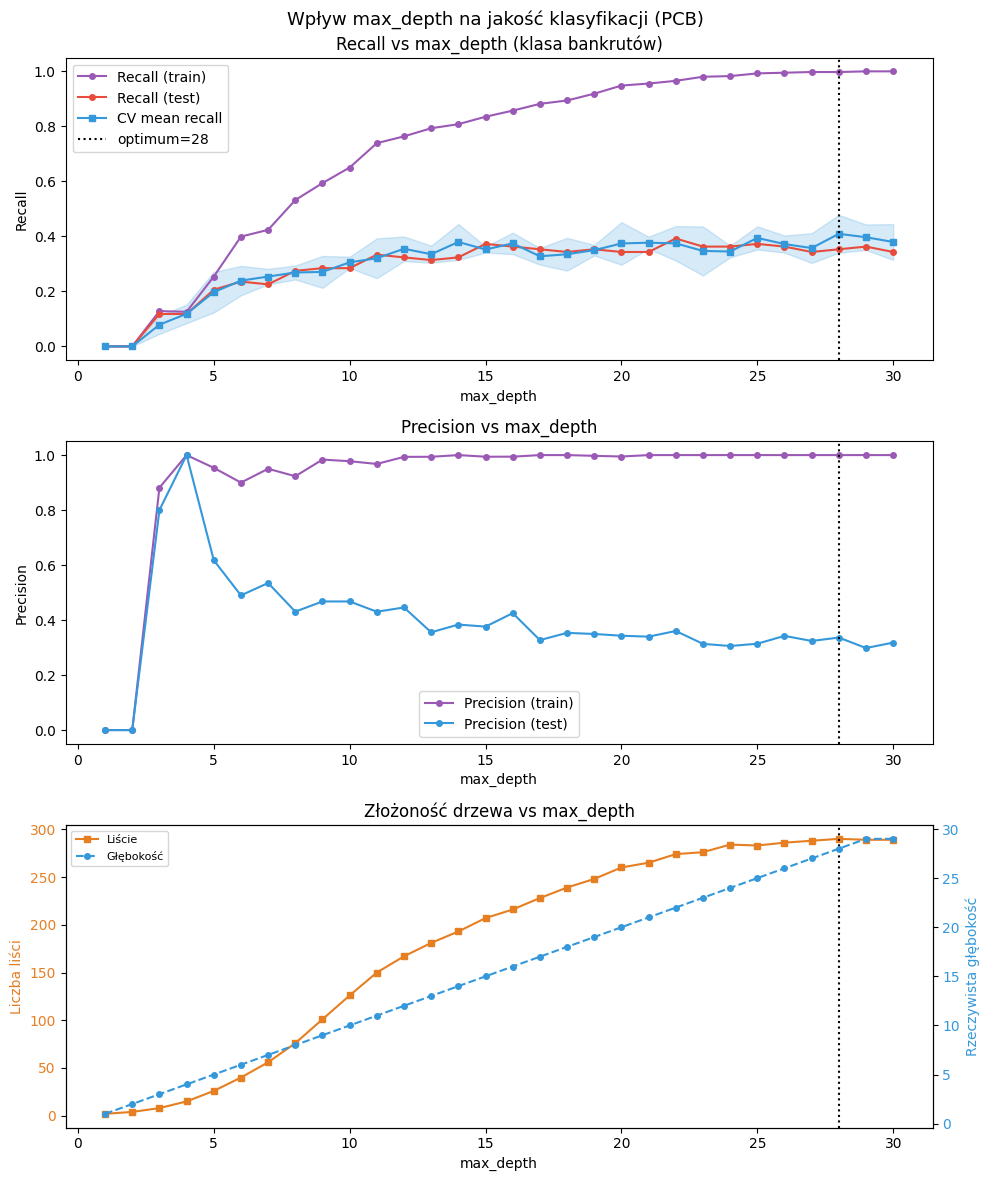

In [115]:
depths = list(range(1, 50))
depth_results_pcb = []

skf = StratifiedKFold(n_splits=5, shuffle=True)

for d in tqdm(depths, desc='max_depth sweep (PCB)'):
    clf = DecisionTreeClassifier(max_depth=d)
    clf.fit(X_pcb_train, y_pcb_train)
    yp_tr = clf.predict(X_pcb_train)
    yp_te = clf.predict(X_pcb_test)
    cv_scores = cross_val_score(clf, X_pcb_train, y_pcb_train, cv=skf, scoring='recall')

    actual_depth = clf.get_depth()
    depth_results_pcb.append({
        'max_depth':    d,
        'actual_depth': actual_depth,
        'cv_mean':      cv_scores.mean(),
        'cv_std':       cv_scores.std(),
        'train_prec':   precision_score(y_pcb_train, yp_tr, zero_division=0),
        'test_prec':    precision_score(y_pcb_test,  yp_te, zero_division=0),
        'train_rec':    recall_score(y_pcb_train, yp_tr, zero_division=0),
        'test_rec':     recall_score(y_pcb_test,  yp_te, zero_division=0),
        'n_leaves':     clf.get_n_leaves(),
    })

    if actual_depth < d:
        print(f'Drzewo nasycone przy max_depth={d} (rzeczywista głębokość={actual_depth}), przerywam sweep.')
        break

df_depth_pcb = pd.DataFrame(depth_results_pcb).set_index('max_depth')
best_depth_pcb = int(df_depth_pcb['cv_mean'].idxmax())
print(f'Najlepsza głębokość (wg CV recall): max_depth={best_depth_pcb}, CV recall={df_depth_pcb.loc[best_depth_pcb, "cv_mean"]:.4f}')

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# 1) Recall: train / test / CV
axes[0].plot(df_depth_pcb.index, df_depth_pcb['train_rec'], color='#9b59b6', marker='o', markersize=4, label='Recall (train)')
axes[0].plot(df_depth_pcb.index, df_depth_pcb['test_rec'],  color='#e74c3c', marker='o', markersize=4, label='Recall (test)')
axes[0].plot(df_depth_pcb.index, df_depth_pcb['cv_mean'],   color='#3498db', marker='s', markersize=4, label='CV mean recall')
axes[0].fill_between(df_depth_pcb.index,
                     df_depth_pcb['cv_mean'] - df_depth_pcb['cv_std'],
                     df_depth_pcb['cv_mean'] + df_depth_pcb['cv_std'],
                     alpha=0.2, color='#3498db')
axes[0].axvline(best_depth_pcb, color='black', linestyle=':', label=f'optimum={best_depth_pcb}')
axes[0].set_ylabel('Recall')
axes[0].set_xlabel('max_depth')
axes[0].tick_params(labelbottom=True)
axes[0].set_title('Recall vs max_depth (klasa bankrutów)')
axes[0].legend()

# 2) Precision: train / test
axes[1].plot(df_depth_pcb.index, df_depth_pcb['train_prec'], color='#9b59b6', marker='o', markersize=4, label='Precision (train)')
axes[1].plot(df_depth_pcb.index, df_depth_pcb['test_prec'],  color='#3498db', marker='o', markersize=4, label='Precision (test)')
axes[1].axvline(best_depth_pcb, color='black', linestyle=':')
axes[1].set_xlabel('max_depth')
axes[1].tick_params(labelbottom=True)
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision vs max_depth')
axes[1].legend()

# 3) Złożoność + rzeczywista głębokość
ax_leaves = axes[2]
ax_depth  = ax_leaves.twinx()
ax_leaves.plot(df_depth_pcb.index, df_depth_pcb['n_leaves'],     color='#e67e22', marker='s', markersize=4, label='Liście')
ax_depth.plot(df_depth_pcb.index,  df_depth_pcb['actual_depth'], color='#3498db', marker='o', markersize=4, linestyle='--', label='Głębokość')
ax_leaves.axvline(best_depth_pcb, color='black', linestyle=':')
ax_leaves.set_ylabel('Liczba liści', color='#e67e22')
ax_depth.set_ylabel('Rzeczywista głębokość', color='#3498db')
ax_leaves.tick_params(axis='y', labelcolor='#e67e22')
ax_depth.tick_params(axis='y', labelcolor='#3498db')
ax_leaves.set_xlabel('max_depth')
ax_leaves.set_title('Złożoność drzewa vs max_depth')
lines1, labels1 = ax_leaves.get_legend_handles_labels()
lines2, labels2 = ax_depth.get_legend_handles_labels()
ax_leaves.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.suptitle('Wpływ max_depth na jakość klasyfikacji (PCB)', fontsize=13)
plt.tight_layout()
plt.show()

### 5.4 `min_samples_leaf` — minimalna liczba próbek w liściu (PCB)

min_samples_leaf sweep (PCB):   0%|          | 0/99 [00:00<?, ?it/s]

Najlepsze min_samples_leaf (wg CV recall): 3, CV recall=0.3893


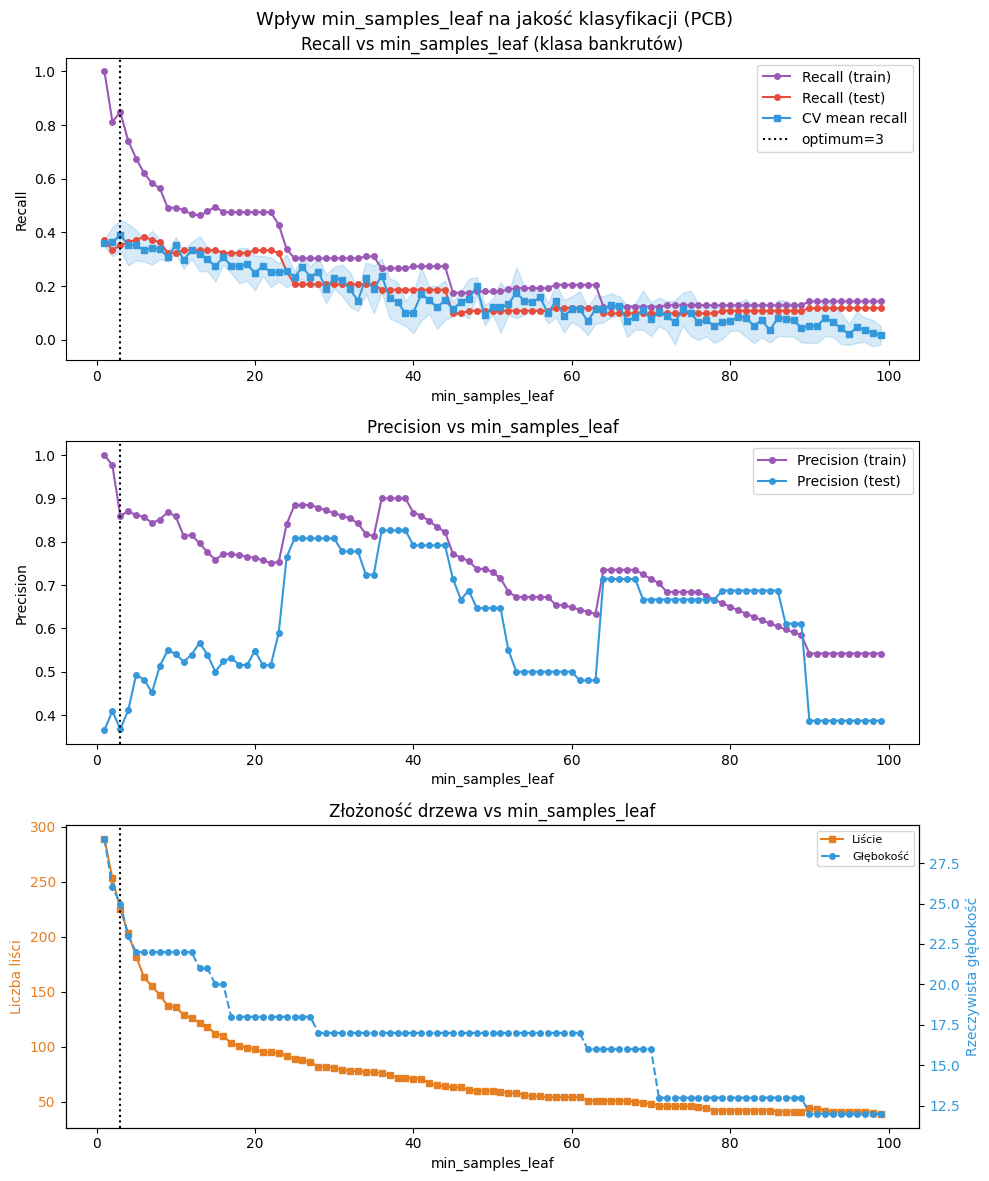

In [116]:
min_samples_values = list(range(1, 100))
leaf_results_pcb = []

skf = StratifiedKFold(n_splits=5, shuffle=True)

for ms in tqdm(min_samples_values, desc='min_samples_leaf sweep (PCB)'):
    clf = DecisionTreeClassifier(min_samples_leaf=ms)
    clf.fit(X_pcb_train, y_pcb_train)
    yp_tr = clf.predict(X_pcb_train)
    yp_te = clf.predict(X_pcb_test)
    cv_scores = cross_val_score(clf, X_pcb_train, y_pcb_train, cv=skf, scoring='recall')

    leaf_results_pcb.append({
        'min_samples_leaf': ms,
        'actual_depth':     clf.get_depth(),
        'cv_mean':          cv_scores.mean(),
        'cv_std':           cv_scores.std(),
        'train_prec':       precision_score(y_pcb_train, yp_tr, zero_division=0),
        'test_prec':        precision_score(y_pcb_test,  yp_te, zero_division=0),
        'train_rec':        recall_score(y_pcb_train, yp_tr, zero_division=0),
        'test_rec':         recall_score(y_pcb_test,  yp_te, zero_division=0),
        'n_leaves':         clf.get_n_leaves(),
    })

df_leaf_pcb = pd.DataFrame(leaf_results_pcb).set_index('min_samples_leaf')
best_ms_pcb = int(df_leaf_pcb['cv_mean'].idxmax())
print(f'Najlepsze min_samples_leaf (wg CV recall): {best_ms_pcb}, CV recall={df_leaf_pcb.loc[best_ms_pcb, "cv_mean"]:.4f}')

fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# 1) Recall: train / test / CV
axes[0].plot(df_leaf_pcb.index, df_leaf_pcb['train_rec'], color='#9b59b6', marker='o', markersize=4, label='Recall (train)')
axes[0].plot(df_leaf_pcb.index, df_leaf_pcb['test_rec'],  color='#e74c3c', marker='o', markersize=4, label='Recall (test)')
axes[0].plot(df_leaf_pcb.index, df_leaf_pcb['cv_mean'],   color='#3498db', marker='s', markersize=4, label='CV mean recall')
axes[0].fill_between(df_leaf_pcb.index,
                     df_leaf_pcb['cv_mean'] - df_leaf_pcb['cv_std'],
                     df_leaf_pcb['cv_mean'] + df_leaf_pcb['cv_std'],
                     alpha=0.2, color='#3498db')
axes[0].axvline(best_ms_pcb, color='black', linestyle=':', label=f'optimum={best_ms_pcb}')
axes[0].set_ylabel('Recall')
axes[0].set_xlabel('min_samples_leaf')
axes[0].tick_params(labelbottom=True)
axes[0].set_title('Recall vs min_samples_leaf (klasa bankrutów)')
axes[0].legend()

# 2) Precision: train / test
axes[1].plot(df_leaf_pcb.index, df_leaf_pcb['train_prec'], color='#9b59b6', marker='o', markersize=4, label='Precision (train)')
axes[1].plot(df_leaf_pcb.index, df_leaf_pcb['test_prec'],  color='#3498db', marker='o', markersize=4, label='Precision (test)')
axes[1].axvline(best_ms_pcb, color='black', linestyle=':')
axes[1].set_ylabel('Precision')
axes[1].set_xlabel('min_samples_leaf')
axes[1].tick_params(labelbottom=True)
axes[1].set_title('Precision vs min_samples_leaf')
axes[1].legend()

# 3) Złożoność + rzeczywista głębokość
ax_leaves = axes[2]
ax_depth  = ax_leaves.twinx()
ax_leaves.plot(df_leaf_pcb.index, df_leaf_pcb['n_leaves'],     color='#e67e22', marker='s', markersize=4, label='Liście')
ax_depth.plot(df_leaf_pcb.index,  df_leaf_pcb['actual_depth'], color='#3498db', marker='o', markersize=4, linestyle='--', label='Głębokość')
ax_leaves.axvline(best_ms_pcb, color='black', linestyle=':')
ax_leaves.set_ylabel('Liczba liści', color='#e67e22')
ax_depth.set_ylabel('Rzeczywista głębokość', color='#3498db')
ax_leaves.tick_params(axis='y', labelcolor='#e67e22')
ax_depth.tick_params(axis='y', labelcolor='#3498db')
ax_leaves.set_xlabel('min_samples_leaf')
ax_leaves.set_title('Złożoność drzewa vs min_samples_leaf')
lines1, labels1 = ax_leaves.get_legend_handles_labels()
lines2, labels2 = ax_depth.get_legend_handles_labels()
ax_leaves.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.suptitle('Wpływ min_samples_leaf na jakość klasyfikacji (PCB)', fontsize=13)
plt.tight_layout()
plt.show()

### 5.5 Pruning drzewa — `ccp_alpha` (PCB)

Liczba kroków pruning path: 132
Zakres ccp_alpha: [0.000000, 0.002645]


ccp_alpha sweep (PCB):   0%|          | 0/132 [00:00<?, ?it/s]

Najlepsza ccp_alpha (wg CV recall): 0.000128, CV recall=0.4213
Wynikowe drzewo: głębokość=27, liście=241


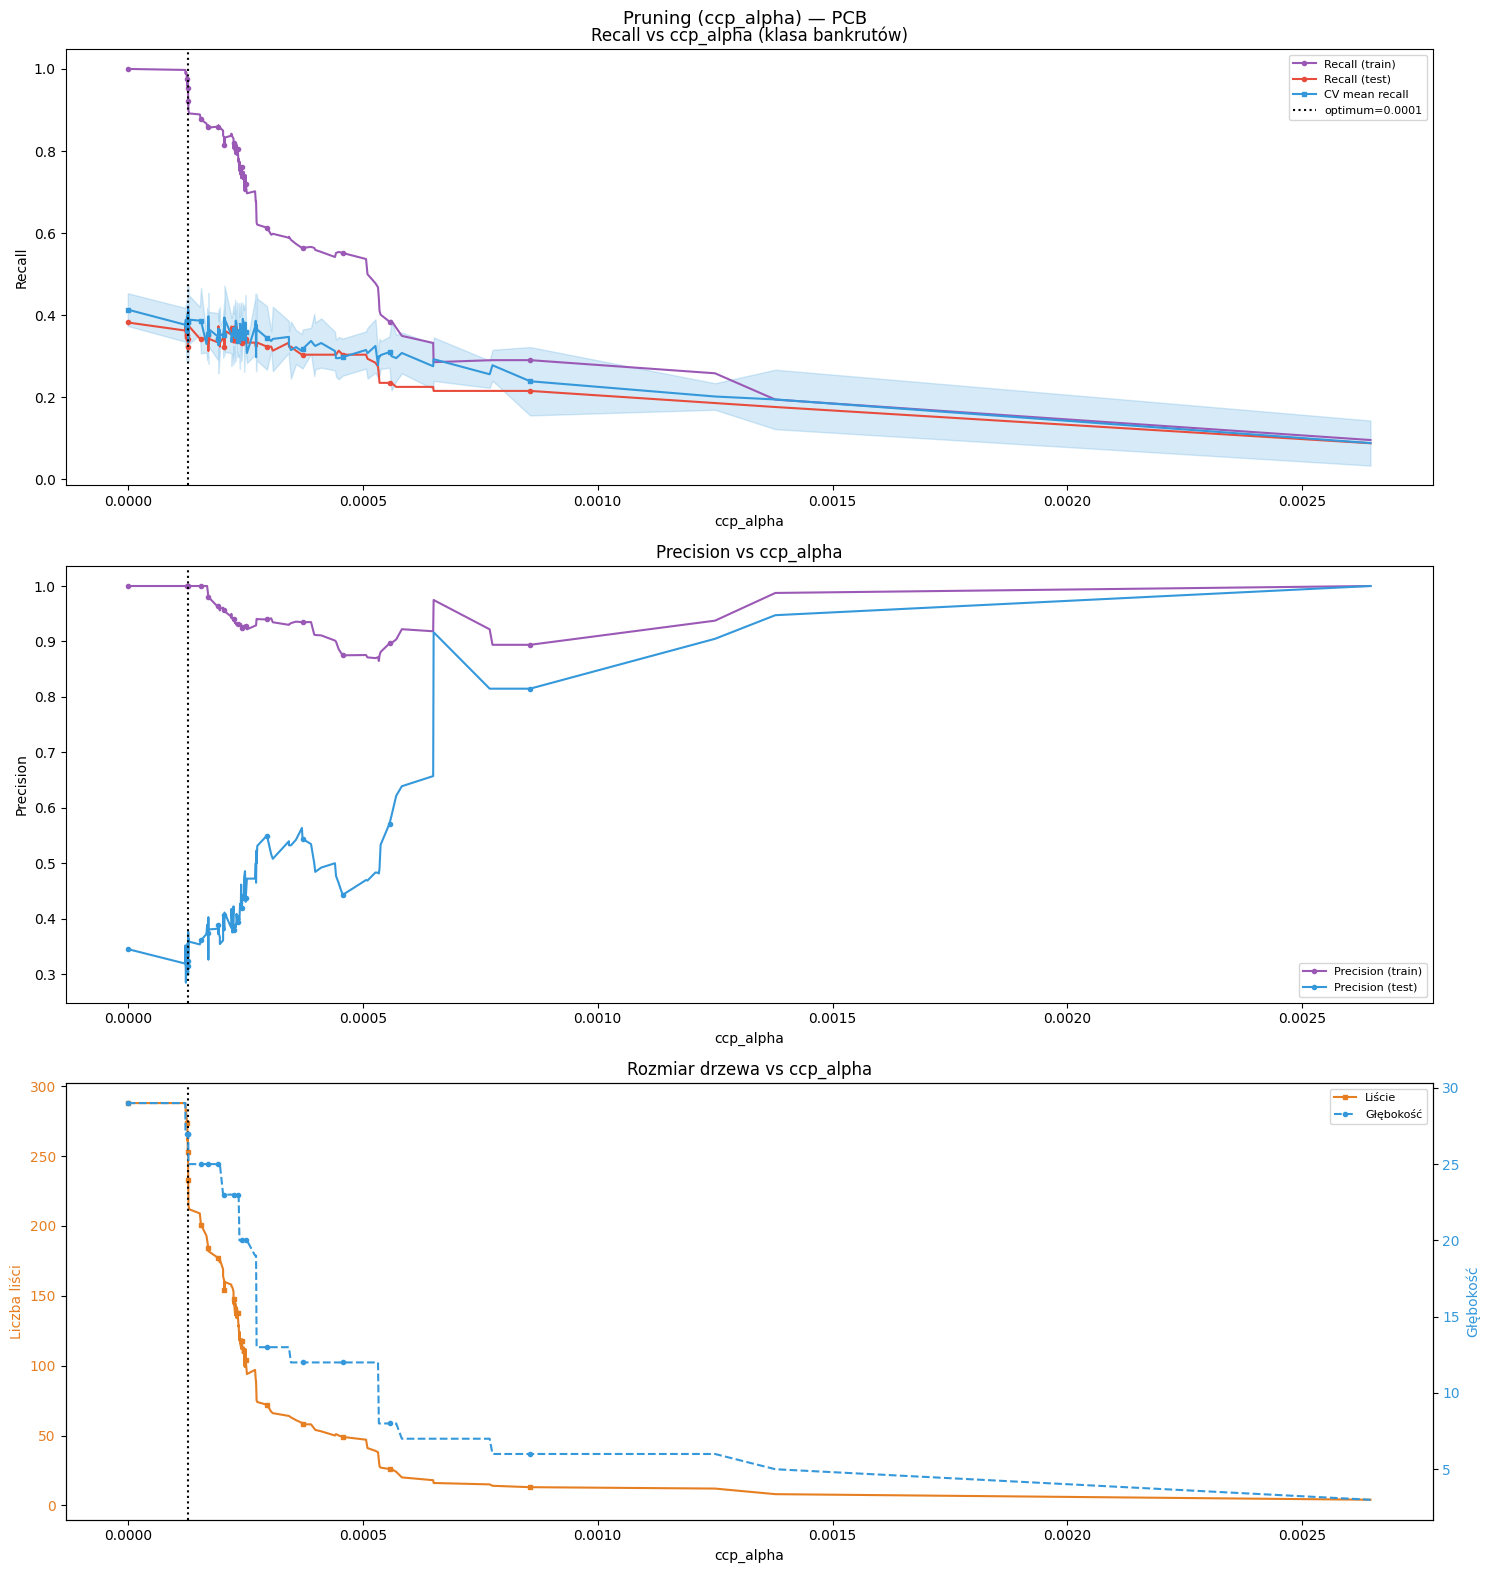

In [133]:
path = DecisionTreeClassifier().cost_complexity_pruning_path(X_pcb_train, y_pcb_train)
ccp_candidates = path.ccp_alphas[:-1]
step = max(1, len(ccp_candidates) // 8)
ccp_grid_pcb = [0.0] + list(ccp_candidates[::step])

skf = StratifiedKFold(n_splits=5, shuffle=True)

print(f'Liczba kroków pruning path: {len(ccp_candidates)}')
print(f'Zakres ccp_alpha: [{ccp_candidates.min():.6f}, {ccp_candidates.max():.6f}]')

alpha_results_pcb = []
for alpha in tqdm(ccp_candidates, desc='ccp_alpha sweep (PCB)'):
    clf = DecisionTreeClassifier(ccp_alpha=alpha)
    clf.fit(X_pcb_train, y_pcb_train)
    yp_tr = clf.predict(X_pcb_train)
    yp_te = clf.predict(X_pcb_test)
    cv_scores = cross_val_score(clf, X_pcb_train, y_pcb_train, cv=skf, scoring='recall')

    alpha_results_pcb.append({
        'ccp_alpha':  alpha,
        'cv_mean':    cv_scores.mean(),
        'cv_std':     cv_scores.std(),
        'train_prec': precision_score(y_pcb_train, yp_tr, zero_division=0),
        'test_prec':  precision_score(y_pcb_test,  yp_te, zero_division=0),
        'train_rec':  recall_score(y_pcb_train, yp_tr, zero_division=0),
        'test_rec':   recall_score(y_pcb_test,  yp_te, zero_division=0),
        'n_leaves':   clf.get_n_leaves(),
        'depth':      clf.get_depth(),
    })

df_alpha_pcb = pd.DataFrame(alpha_results_pcb)
best_alpha_idx_pcb = df_alpha_pcb['cv_mean'].idxmax()
best_row_pcb       = df_alpha_pcb.loc[best_alpha_idx_pcb]
best_alpha_pcb     = float(best_row_pcb['ccp_alpha'])

print(f'Najlepsza ccp_alpha (wg CV recall): {best_alpha_pcb:.6f}, CV recall={best_row_pcb["cv_mean"]:.4f}')
print(f'Wynikowe drzewo: głębokość={int(best_row_pcb["depth"])}, liście={int(best_row_pcb["n_leaves"])}')

n_points  = len(df_alpha_pcb)
markevery = max(1, n_points // 15)

fig, axes = plt.subplots(3, 1, figsize=(15, 16), sharex=True)

# 1) Recall: train / test / CV
axes[0].plot(df_alpha_pcb['ccp_alpha'], df_alpha_pcb['train_rec'], color='#9b59b6', linewidth=1.5, marker='o', markersize=3, markevery=markevery, label='Recall (train)')
axes[0].plot(df_alpha_pcb['ccp_alpha'], df_alpha_pcb['test_rec'],  color='#e74c3c', linewidth=1.5, marker='o', markersize=3, markevery=markevery, label='Recall (test)')
axes[0].plot(df_alpha_pcb['ccp_alpha'], df_alpha_pcb['cv_mean'],   color='#3498db', linewidth=1.5, marker='s', markersize=3, markevery=markevery, label='CV mean recall')
axes[0].fill_between(df_alpha_pcb['ccp_alpha'],
                     df_alpha_pcb['cv_mean'] - df_alpha_pcb['cv_std'],
                     df_alpha_pcb['cv_mean'] + df_alpha_pcb['cv_std'],
                     alpha=0.2, color='#3498db')
axes[0].axvline(best_alpha_pcb, color='black', linestyle=':', label=f'optimum={best_alpha_pcb:.4f}')
axes[0].set_ylabel('Recall')
axes[0].set_xlabel('ccp_alpha')
axes[0].tick_params(labelbottom=True)
axes[0].set_title('Recall vs ccp_alpha (klasa bankrutów)')
axes[0].legend(fontsize=8)

# 2) Precision: train / test
axes[1].plot(df_alpha_pcb['ccp_alpha'], df_alpha_pcb['train_prec'], color='#9b59b6', linewidth=1.5, marker='o', markersize=3, markevery=markevery, label='Precision (train)')
axes[1].plot(df_alpha_pcb['ccp_alpha'], df_alpha_pcb['test_prec'],  color='#3498db', linewidth=1.5, marker='o', markersize=3, markevery=markevery, label='Precision (test)')
axes[1].axvline(best_alpha_pcb, color='black', linestyle=':')
axes[1].set_ylabel('Precision')
axes[1].set_xlabel('ccp_alpha')
axes[1].tick_params(labelbottom=True)
axes[1].set_title('Precision vs ccp_alpha')
axes[1].legend(fontsize=8)

# 3) Rozmiar drzewa
ax_leaves = axes[2]
ax_depth  = ax_leaves.twinx()
ax_leaves.plot(df_alpha_pcb['ccp_alpha'], df_alpha_pcb['n_leaves'], color='#e67e22', linewidth=1.5, marker='s', markersize=3, markevery=markevery, label='Liście')
ax_depth.plot(df_alpha_pcb['ccp_alpha'],  df_alpha_pcb['depth'],    color='#3498db', linewidth=1.5, marker='o', markersize=3, markevery=markevery, linestyle='--', label='Głębokość')
ax_leaves.axvline(best_alpha_pcb, color='black', linestyle=':')
ax_leaves.set_xlabel('ccp_alpha')
ax_leaves.set_ylabel('Liczba liści', color='#e67e22')
ax_depth.set_ylabel('Głębokość', color='#3498db')
ax_leaves.tick_params(axis='y', labelcolor='#e67e22')
ax_depth.tick_params(axis='y', labelcolor='#3498db')
lines1, labels1 = ax_leaves.get_legend_handles_labels()
lines2, labels2 = ax_depth.get_legend_handles_labels()
ax_leaves.legend(lines1 + lines2, labels1 + labels2, fontsize=8)
ax_leaves.set_title('Rozmiar drzewa vs ccp_alpha')

plt.suptitle('Pruning (ccp_alpha) — PCB', fontsize=13)
plt.tight_layout()
plt.show()

KFold: CV recall=0.5001 ± 0.0953
  Wyniki foldów: [0.611 0.419 0.423 0.425 0.622]
StratifiedKFold: CV recall=0.5050 ± 0.0326
  Wyniki foldów: [0.531 0.469 0.519 0.543 0.463]

Metryka                      KFold    StratifiedKFold
-------------------------------------------------------
Precision                   0.2059             0.2119
Recall                      0.5490             0.5588


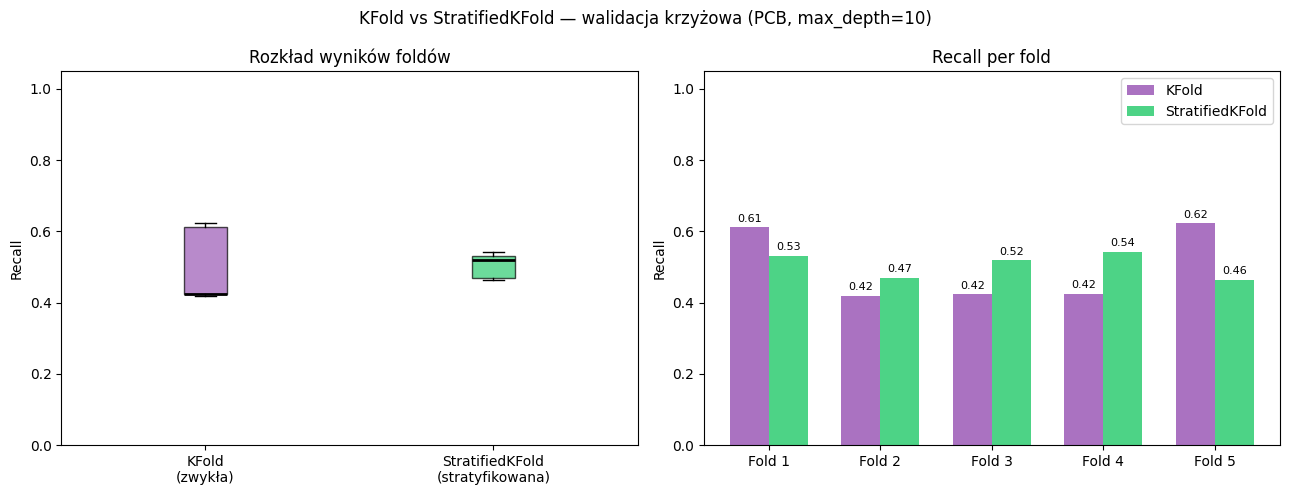

In [158]:
kf  = KFold(n_splits=5, shuffle=True)
skf = StratifiedKFold(n_splits=5, shuffle=True)

results_per_cv_pcb = {}
for cv_name, cv in [('KFold', kf), ('StratifiedKFold', skf)]:
    clf = DecisionTreeClassifier(max_depth=10, class_weight='balanced')
    scores = cross_val_score(clf, X_pcb_train, y_pcb_train, cv=cv, scoring='recall')

    clf_final = DecisionTreeClassifier(max_depth=10, class_weight='balanced')
    clf_final.fit(X_pcb_train, y_pcb_train)
    yp = clf_final.predict(X_pcb_test)

    results_per_cv_pcb[cv_name] = {
        'cv_scores': scores,
        'cv_mean':   scores.mean(),
        'cv_std':    scores.std(),
        'clf':       clf_final,
        'y_pred':    yp,
    }
    print(f'{cv_name}: CV recall={scores.mean():.4f} ± {scores.std():.4f}')
    print(f'  Wyniki foldów: {np.round(scores, 3)}')

print(f'\n{"Metryka":<15}', end='')
for cv_name in results_per_cv_pcb:
    print(f' {cv_name:>18}', end='')
print()
print('-' * 55)
for metric_name, fn, kw in [
    ('Precision', precision_score, {'zero_division': 0}),
    ('Recall',    recall_score,    {'zero_division': 0}),
]:
    print(f'{metric_name:<15}', end='')
    for res in results_per_cv_pcb.values():
        val = fn(y_pcb_test, res['y_pred'], **kw)
        print(f' {val:>18.4f}', end='')
    print()

scores_kf  = results_per_cv_pcb['KFold']['cv_scores']
scores_skf = results_per_cv_pcb['StratifiedKFold']['cv_scores']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# boxplot
bp = axes[0].boxplot([scores_kf, scores_skf],
                     tick_labels=['KFold\n(zwykła)', 'StratifiedKFold\n(stratyfikowana)'],
                     patch_artist=True)
for patch, color in zip(bp['boxes'], ['#9b59b6', '#2ecc71']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for med in bp['medians']:
    med.set_color('black')
    med.set_linewidth(2)
axes[0].set_title('Rozkład wyników foldów')
axes[0].set_ylabel('Recall')
axes[0].set_ylim(0, 1.05)

# bars per fold
x = np.arange(5)
width = 0.35
fold_labels = [f'Fold {i+1}' for i in range(5)]
bars_kf  = axes[1].bar(x - width/2, scores_kf,  width, color='#9b59b6', alpha=0.85, label='KFold')
bars_skf = axes[1].bar(x + width/2, scores_skf, width, color='#2ecc71', alpha=0.85, label='StratifiedKFold')
for bars in [bars_kf, bars_skf]:
    for bar in bars:
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(fold_labels)
axes[1].set_title('Recall per fold')
axes[1].set_ylabel('Recall')
axes[1].set_ylim(0, 1.05)
axes[1].legend()

plt.suptitle('KFold vs StratifiedKFold — walidacja krzyżowa (PCB, max_depth=10)', fontsize=12)
plt.tight_layout()
plt.show()

### 5.3 Wpływ parametru `class_weight`

class_weight:   0%|          | 0/6 [00:00<?, ?it/s]

,Accuracy,Precision,Recall,F1,Głębokość,Liście
class_weight,,,,,,
None,0.9450,0.4603,0.2843,0.3515,10,126
balanced,0.8683,0.2127,0.5588,0.3081,10,177
"{0:1, 1:5}",0.9239,0.3203,0.4020,0.3565,10,146
"{0:1, 1:20}",0.8621,0.2098,0.5882,0.3093,10,145
"{0:1, 1:50}",0.8076,0.1600,0.6275,0.2550,10,108
"{0:1, 1:100}",0.7099,0.1188,0.7059,0.2034,10,83


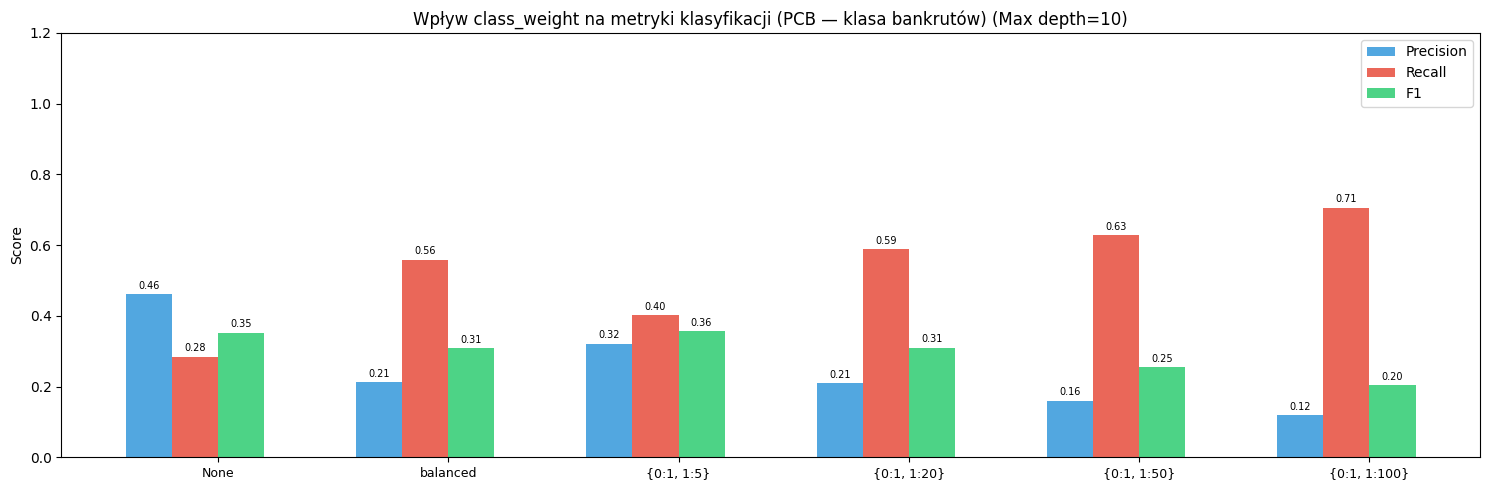

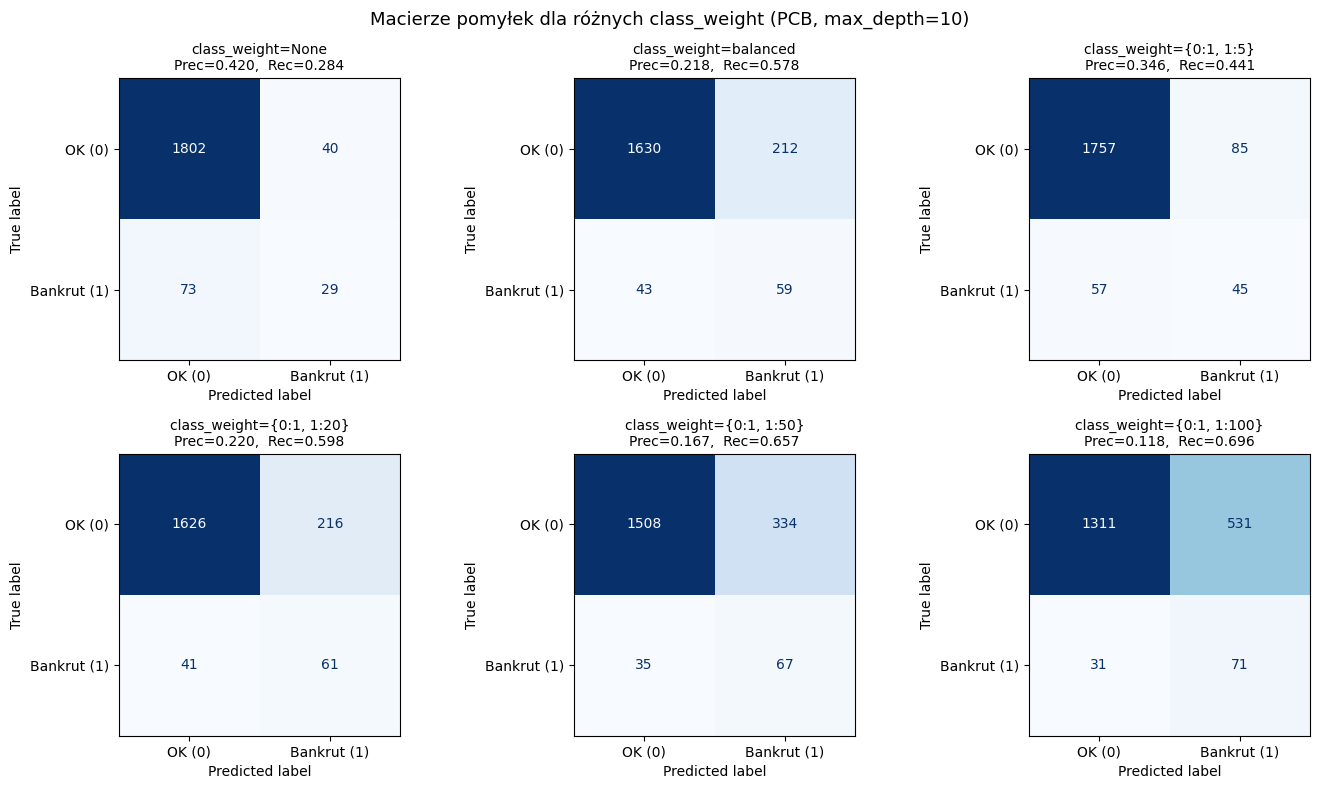

In [119]:
class_weight_variants = [
    ('None',        None),
    ('balanced',    'balanced'),
    ('{0:1, 1:5}',  {0: 1, 1: 5}),
    ('{0:1, 1:20}', {0: 1, 1: 20}),
    ('{0:1, 1:50}', {0: 1, 1: 50}),
    ('{0:1, 1:100}', {0: 1, 1: 100}),
]

cw_results = []
for name, cw in tqdm(class_weight_variants, desc='class_weight'):
    clf = DecisionTreeClassifier(class_weight=cw, max_depth=10)
    clf.fit(X_pcb_train, y_pcb_train)
    yp = clf.predict(X_pcb_test)
    cw_results.append({
        'class_weight': name,
        'Accuracy':  accuracy_score(y_pcb_test, yp),
        'Precision': precision_score(y_pcb_test, yp, zero_division=0),
        'Recall':    recall_score(y_pcb_test,    yp, zero_division=0),
        'F1':        f1_score(y_pcb_test,        yp, zero_division=0),
        'Głębokość': clf.get_depth(),
        'Liście':    clf.get_n_leaves(),
    })

df_cw = pd.DataFrame(cw_results).set_index('class_weight')
display(df_cw.round(4))

fig, ax = plt.subplots(figsize=(15, 5))
x = np.arange(len(df_cw))
width = 0.2
metrics_colors = [('Precision', '#3498db'), ('Recall', '#e74c3c'), ('F1', '#2ecc71')]
offsets = [-1.5, -0.5, 0.5, 1.5]

for (metric, color), offset in zip(metrics_colors, offsets):
    bars = ax.bar(x + offset * width, df_cw[metric], width, label=metric, color=color, alpha=0.85)
    for bar in bars:
        if bar.get_height() > 0.02:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(df_cw.index, fontsize=9)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.2)
ax.set_title('Wpływ class_weight na metryki klasyfikacji (PCB — klasa bankrutów) (Max depth=10)')
ax.legend()
plt.tight_layout()
plt.show()


n = len(class_weight_variants)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, (res, (name, _)) in zip(axes.flatten(), zip(cw_results, class_weight_variants)):
    clf = DecisionTreeClassifier(class_weight=_[1] if isinstance(_, tuple) else _, max_depth=10)
    clf.fit(X_pcb_train, y_pcb_train)
    yp = clf.predict(X_pcb_test)
    cm = confusion_matrix(y_pcb_test, yp)
    disp = ConfusionMatrixDisplay(cm, display_labels=['OK (0)', 'Bankrut (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    prec = precision_score(y_pcb_test, yp, zero_division=0)
    rec  = recall_score(y_pcb_test,    yp, zero_division=0)
    ax.set_title(f'class_weight={name}\nPrec={prec:.3f},  Rec={rec:.3f}', fontsize=10)

plt.suptitle('Macierze pomyłek dla różnych class_weight (PCB, max_depth=10)', fontsize=13)
plt.tight_layout()
plt.show()